
# Fall 2025 AE-401 Project 1 - Part 1


# Single-stage to orbit: The lunar case


Modified by: <br>
<!-- + Write your name below + -->      
<br>

Kaoutar Ammara <br>
Department of Aerospace Engineering <br>
Izmir University of Economics <br> 

email: a.kaoutar2001@gmail.com 

Created: 15 November 2023 <br>
Last updated: 9 November 2025 <br>  

*Cite as:* Fabrizio Pinto. (27 November 2025). *Exercises in Rocket Propulsion. Single-stage to orbit: The lunar case (Jupyter Notebook v. 1.1)*. Retrieved from https://osf.io/rxnhy/ 

<span style='color:red'>  *This is ver. 1.2 of this document. Any updates will appear as separate, follow-up
versions.</span> 

<div class="alert alert-block alert-info">
<span style='color:black'>  "Single-stage to orbit: Lunar case" by Fabrizio Pinto is licensed under a Creative Commons Attribution 4.0 International License, except where otherwise noted.</span> <br> 
    
https://creativecommons.org/licenses/by/4.0/   </div> 

 <div class="alert alert-block alert-info"> <span style='color:black'>
${\mathbf{Attribution}}$ — You must give appropriate credit, provide a link to the license, and indicate if changes were made. You may do so in any reasonable manner, but not in any way that suggests the licensor endorses you or your use. </div> 

## <a class="anchor" id="Table_of_Contents"></a> Table of Contents 

[Abstract](#Abstract) 

[1. Constants and useful parameters](#1_Constants_and_useful_parameters)

[2. Introduction](#2_Introduction)

[3. Relevant orders of magnitude ](#3_Relevant_orders_of_magnitude)   

&emsp; [3.1 Estimates of the $\Delta v$ from the $2$-body problem](#3.1_two-body-problem) 

&emsp; [3.2 Estimates from the rocket equation](#3.2_Rocket_equation)

&emsp; [3.3 Mass flow and burn time](#3.3_Mass_flow_and_burn_time)
 
[4. Rocket motion under the combined effect of gravity and thrust ](#4_The_equation_of_motion) 

&emsp; [4.1 Code verification: Vertical flight ](#4.1_Code_verification_vertical_flight)

&emsp; [4.2 Linear-Tangent Steering Laws](#4.2_Linear_Tangent_Steering_Laws)

&emsp; &emsp; [4.2.1 Takeoff at a thrusting angle equal to $\phi_0$](#4.2.1_Takeoff_at_a_thrusting_angle_equal_to)

&emsp; &emsp; [4.2.2 Vertical takeoff to a linear tangent law](#4.2.2_Vertical_takeoff_to_a_linear_tangent_law)

[5. Questions](#5_Questions) 

[References](#References)   

## <a class="anchor" id="Abstract"></a> Abstract 

[Back to Table of Contents](#Table_of_Contents)

In this document, we first analyze the ascent of the Apollo LEM by direct numerical integration of the equations of motion in circular polar coordinates ($2$D). The know-how accumulated from this analysis is then used to analyze ascent in other lunar missions.   

## <a class="anchor" id="1_Constants_and_useful_parameters"></a> 1. Constants and useful parameters

[Back to Table of Contents](#Table_of_Contents)  

Only SI units are used: 

In [25]:
gEarth = 9.8066; 
kMoon = 4.9048695 10^(12) ; 
RadiusMoon = 1.7374 10^6 ;

gMoon = kMoon / (RadiusMoon^2)  

(*Imperial units*)

NauticalMile = 1852;
ft = 0.3048;
(*lb force to Newton*)
lbf = 4.44822; 
(*lb of mass to kg*)
lb = 0.45359237;

1.6249

where

$$
k_{\mathrm{Moon}} = G M_{\mathrm{Moon}}
$$

is the *standard gravitational parameter* of the Moon and the Moon is assumed to be spherical and of radius equal to $R_{\mathrm{Moon}}$. 

## <a class="anchor" id="2_Introduction"></a>  2. Introduction 

[Back to Table of Contents](#Table_of_Contents) 

In this Jupyter Notebook, 

$$
I = \int\,\,\, {\mathrm{d}}x\, e^{-x}\, \sin x\, ,\tag{1}
$$


## <a class="anchor" id="3_Relevant_orders_of_magnitude"></a>  3. Relevant orders of magnitude 

[Back to Table of Contents](#Table_of_Contents) 


Escape velocity from the lunar surface:

$$
v_{\mathrm{esc}} = \sqrt{{2 k_{\mathrm{Moon}}\over r}}\, , \tag{1}
$$

In [48]:
vesc [r_] = Sqrt[(2 kMoon)/r] ;

In [49]:
vesc [RadiusMoon]

2376.18

Circular orbit speed:

$$
v_{\mathrm{circ}} = \sqrt{{k_{\mathrm{Moon}}\over r}}\, , \tag{2}
$$

In [54]:
vcirc [r_] = Sqrt[(kMoon)/r] ;

The circular orbit speed of the CSM at a altitude of $110$ km is:

In [59]:
vcirc [(RadiusMoon + 110 10^3)] 

1629.42

### <a class="anchor" id="3.1_two-body-problem"></a>  3.1 Estimates of the $\Delta v$ from the $2$-body problem

[Back to Table of Contents](#Table_of_Contents)  

Here we estimate the $\Delta v$ needed to climb from ground level to the preliminary orbit with periapsis and apoapsis altitudes of $9\times 45$ nmi. discussed in Bennett (pp. 13-16). Notice that  $1$ nautical mile = 1852 m (https://en.wikipedia.org/wiki/Nautical_mile). 

Defining the semimajor axis and the eccentricity as:

$$
a = {1\over 2} (r_a + r_p)\, ,
$$

$$
e =  {r_a - r_p\over r_a + r_p}\, ,
$$

where 

$r_p = R_{\mathrm{Moon}}$ and $r_a = R_{\mathrm{Moon}} + H_{\mathrm{fin}}$. 


In [64]:
SMA[rp_, ra_] = (1/2) (rp + ra);
Eccentricity[rp_, ra_] = (ra - rp)/(ra + rp) ;

The specific angular momentum is (Bate et al., Sec. 1.6):

$$
\ell = r_p v_p = r_a v_a = \sqrt{k_{\mathrm{Moon}} a (1-e^2)}\, ,
$$



In [70]:
SpecAngMom [rp_, ra_] = Sqrt[kMoon SMA[rp, ra] ((1 - (Eccentricity[rp, ra])^2))]; 

In [71]:
vp [rp_, ra_] =  (SpecAngMom [rp, ra])/rp;
va [rp_, ra_] =  (SpecAngMom [rp, ra])/ra; 

In [73]:
(*altitude at periapsis and apoapsis, in m*) 

9 NauticalMile

45 NauticalMile

16668
83340

In [76]:
vp [RadiusMoon + 9 NauticalMile, (RadiusMoon + 45 NauticalMile)]
va [RadiusMoon + 9 NauticalMile, (RadiusMoon + 45 NauticalMile)] 

1687.73
1625.93

The total $\Delta v$ to achieve the speed needed to be at periapsis from rest is, therefore:

In [82]:
TotDeltaV [rp_, ra_] = Abs[(vp [rp, ra])] ;

In [83]:
TotDeltaV [RadiusMoon + 9 NauticalMile, (RadiusMoon + 45 NauticalMile)] 

1687.73

Since NASA documents of the time use imperial units, it may be useful to convert the $\Delta v$ to ft/s:

In [88]:
TotDeltaV [RadiusMoon + 9 NauticalMile, (RadiusMoon + 45 NauticalMile)] / ft

5537.17

### <a class="anchor" id="3.2_Rocket_equation"></a>  3.2 Estimates from the rocket equation 

[Back to Table of Contents](#Table_of_Contents)  

In this Section, we make use of the rocket equation to estimate some fundamental parameters that will be useful in preparation for the numerical integration of the problem. This treatment parallels that by Turner (Ch. 5). 

By writing the rocket equation as:

$$
\Delta v = v_{\mathrm{exh}}\, \ln {M_{\mathrm{in}}\over M_{\mathrm{fin}}}\, ,
$$
we find:

$$
{\cal{M}} \equiv {M_{\mathrm{in}}\over M_{\mathrm{fin}}} = e^{\displaystyle{\Delta v/ v_{\mathrm{exh}}}}\, ,
$$
where the gravitational acceleration was neglected. 

The exhaust velocity is written in terms of the specific impulse as usual:

$$
v_{\mathrm{exh}} = I_s g_\oplus\, . 
$$ 

Information pertaining to the lunar ascent engine is summarized at https://en.wikipedia.org/wiki/Ascent_propulsion_system#References and http://www.alternatewars.com/BBOW/Space/Reference_Spacecraft_Engines.htm . An in-depth historical discussion is given by Fisher and Rahman (Ch. 7). 

We shall assume:

$$
I_s = 311\, {\mathrm{s}};
$$

$$
F_{\mathrm{th}} = 3500\, {\mathrm{lbf}}\, ;
$$


In [93]:
vexh [ISP_] = ISP gEarth ;

The exhaust velocity at the given $I_s$ is:

In [98]:
vexh [311]

3049.85

The mass ratio for the $\Delta v$ calculated above becomes:

In [103]:
MassRatio [rp_, ra_, ISP_] = Exp[((TotDeltaV [rp, ra])/(vexh [ISP]))];

In [104]:
MassRatio [RadiusMoon + 9 NauticalMile, (RadiusMoon + 45 NauticalMile), 311]

1.73912

The following information about the lunar ascent stage is available in the literature (https://en.wikipedia.org/wiki/Apollo_Lunar_Module#Ascent_stage): 

Launch mass: $4,700$ kg <br>
Dry mass: $2,150$ kg <br> 

With this information:

In [113]:
(*Launch mass in kg*)

MassRocket0 = 4700.

(*Launch mass - dry mass*) 

(4700-2150)
(4700-2150)/lb

(*Usable fuel mass from Bennett, p 15, Note a*) 

MassUsableFuel = (2026+3218.4) lb
2026+3218.4 

(*Theoretical Delta v from usable fuel mass*)

(vexh [311] Log[N[(4700)/(4700 - (2026+3218.4) lb)]]) 
(vexh [311] Log[N[(4700)/(4700 - (2026+3218.4) lb)]]) / ft

4700.
2550
5621.79
2378.82
5244.4
2151.63
7059.16

Notice that $M_{\mathrm{launch}} - M_{\mathrm{dry}} > M_{\mathrm{fuel,\, usable}}$. 

From the above estimate, the fuel needed shall be: 

$$
M_{\mathrm{fuel}} = M_{\mathrm{in}} \Bigl(1- {1\over {\cal{M}}}\Bigr)\, .
$$

In [128]:
MassRocket0 - MassRocket0/MassRatio [RadiusMoon + 9 NauticalMile, (RadiusMoon + 45 NauticalMile), 311]

1997.49

### <a class="anchor" id="3.3_Mass_flow_and_burn_time"></a>  3.3 Mass flow and burn time 

[Back to Table of Contents](#Table_of_Contents)  

The rated thrust of the lunar ascent stage (LAS) is, in Newton:

In [137]:
FThrustLAS = 3500 lbf

15568.8

In [138]:
FThrustLAS / gEarth

1587.58

This allows us to obtain the mass flow as:

In [143]:
mdot[ISP_] = FThrustLAS / vexh [ISP]; 
mdot[311] 
vexh [311] 
mdot[311] vexh [311] 

5.10476
3049.85
15568.8

Therefore we can write the vehicle mass and the maximum burn time as:

In [151]:
MassRocket [ISP_, t_] =  MassRocket0 - mdot[ISP] t ;

BurnOutTimeMax [ISP_] = MassUsableFuel/(mdot[ISP]) ;

BurnOutTimeMax [311]

466.

The above result must be compared with https://en.wikipedia.org/wiki/Ascent_propulsion_system , where $T_{\mathrm{burn,\, tot}} = 465 \, {\mathrm{s}}$ is given. 

## <a class="anchor" id="4_The_equation_of_motion"></a> 4. Rocket motion under the combined effect of gravity and thrust 

[Back to Table of Contents](#Table_of_Contents) 



$$
{\mathbf{F_{th}}} = \dot{m}\, v_{\mathrm{exh}}\,  {\hat{\mathbf{n}}_{\mathrm{th}}}
$$

where ${\hat{\mathbf{n}}_{\mathrm{th}}}$ is the thrust versor.

A coupled differential equation approch is needed because angular momentum is no longer conserved. 


Therefore, by projecting the vector ${\mathbf{F_{th}}}$ along the $\hat{\mathbf{r}}$ versor, and by using 
${\hat{\mathbf{r}}}\cdot {\hat{\mathbf{n}}_{\mathrm{th}}} = \cos\theta_{\mathrm{th}}$, where $\theta_{\mathrm{th}} (t)$ is the angle between the radial and the thrust vector, the radial equation of motion is modified by the additional thrust term as follows:  

$$
\ddot{r}_{\mathrm{th}} = {1\over m}{\mathbf{F_{th}}}\cdot {\hat{\mathbf{r}}} =  
{\dot{m}v_{\mathrm{exh}}\over m(t)}\, \cos\theta_{\mathrm{th}}\, ,
$$ 

This term must be added to the standard equation for the $2$-body problem as:

$$
\ddot{r} = r \dot{\theta}^2 - {k_\oplus\over r^2} + \ddot{r}_{\mathrm{th}}\, .
$$
As far as the polar coordinate, angular momentum is, in general, no longer conserved (Kittel et al., p. 281), so that:

$$
{1\over r} {{\mathrm{d}}\over {\mathrm{d}}t} \Bigl(r^2 \dot{\theta}\Bigr) = {1\over m}{\mathbf{F_{th}}}\cdot {\hat{\theta}}
= {\dot{m}v_{\mathrm{exh}}\over m(t)}\, \sin\theta_{\mathrm{th}}
\, .
$$
Finally, since:
$$
{1\over r} {{\mathrm{d}}\over {\mathrm{d}}t} \Bigl(r^2 \dot{\theta}\Bigr) = 2 \dot{r}\dot{\theta} + r \ddot{\theta}
$$
we have, dividing by $r$ overall:

$$
\ddot{\theta} = -2 {1\over r}\dot{r}\dot{\theta} + {1\over r} {\dot{m}v_{\mathrm{exh}}\over m(t)}\, \sin\theta_{\mathrm{th}} 
\, .
$$ 

To summarize:

$$
\begin{cases}
\ddot{r} = r \dot{\theta}^2 - \displaystyle{k_\oplus\over r^2} + {\dot{m}v_{\mathrm{exh}}\over m(t)}\, \cos\theta_{\mathrm{th}} \, , \\
\ddot{\theta} = -2 \displaystyle{1\over r}\dot{r}\dot{\theta}  +  {1\over r} {\dot{m}v_{\mathrm{exh}}\over m(t)}\, \sin\theta_{\mathrm{th}} 
\, .
\end{cases}
$$

In order to adopt a notation more consistent with typical treatments (Thomson 1986, Sec. 8.3), we shall use the angle $\phi_{\mathrm{th}} = \pi/2 - \theta_{\mathrm{th}}$, where $\phi_{\mathrm{th}}$ is the angle above the burnout horizontal.  

$$
\begin{cases}
\ddot{r} = r \dot{\theta}^2 - \displaystyle{k_\oplus\over r^2} + {\dot{m}v_{\mathrm{exh}}\over m(t)}\, \sin\phi_{\mathrm{th}} \, , \\
\ddot{\theta} = -2 \displaystyle{1\over r}\dot{r}\dot{\theta}  +  {1\over r} {\dot{m}v_{\mathrm{exh}}\over m(t)}\, \cos\phi_{\mathrm{th}} 
\, .
\end{cases}
$$

In this case, it is impossible to uncouple the two coordinates and the problem must be solved as a system of simultaneous differential equations. 


In [162]:
(*do not use*)
MassRocket [t_] = M0 - mdotNum t ; 

### <a class="anchor" id="4.1_Code_verification_vertical_flight"></a>  4.1 Code verification: Vertical flight 

[Back to Table of Contents](#Table_of_Contents)  


In order to verify that the code was correctly designed, we shall first of all test it in vertical flight ($\phi_{\mathrm{th}}  = \pi/2$). As an example, we shall consider the case of a rocket released from rest at the lunar surface with a thrust level just below that needed to achieve an initial hover, that is, for instance, with $|{\mathbf{F_{th}}}| = 0.99\, m(0) g_{\mathrm{Moon}}$. 

The initial conditions are: 

$$
\begin{cases}
r(0) = R_{\mathrm{Moon}} \, , \\
\dot{r}(0) = 0 \, , \\ 
\theta(0) = 0\, , \\ 
\dot{\theta}(0) = 0\, .
\end{cases}
$$



In [172]:
r0 = RadiusMoon 
rdot0 = 0.0 
ThetaSC0 = 0.0
ThetaAngSCdot0 = 0

6
1.7374 10
0.
0.
0

The interesting evalution of the system occurs in the first few seconds:

In [180]:
tfin = 30.

30.

The condition of vertical thrust is imposed by choosing:

In [185]:
ThrustPhi[t_] = 90 Degree 

90 Degree

In [186]:
MassRocket [311, t]

4700. - 5.10476 t

{0., {{rSC -> InterpolatingFunction[{{0., 30.}}, <>], 
 
>     ThetaAngSC -> InterpolatingFunction[{{0., 30.}}, <>]}}}
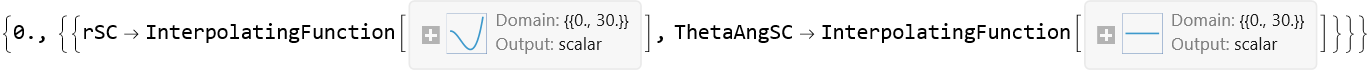

In [187]:
(*Note: Thrust is set at: 0.99 MassRocket [311, 0] gMoon instead of: mdot[311] vexh [311]*)
Timing[Thrust2BP = NDSolve[
                {rSC''[t] == (rSC[t] (ThetaAngSC'[t]^2)) - (kMoon/(rSC[t])^2) + (0.99 MassRocket [311, 0] gMoon /MassRocket [311, t]) Sin[ThrustPhi[t]], 
                ThetaAngSC''[t]==-(2/rSC[t])rSC'[t]ThetaAngSC'[t] + (1/rSC[t])(0.99 MassRocket [311, 0] gMoon /MassRocket [311, t]) Cos[ThrustPhi[t]], 
                rSC[0]==r0,rSC'[0]==rdot0,ThetaAngSC[0]==ThetaSC0,ThetaAngSC'[0]==ThetaAngSCdot0},
                {rSC,ThetaAngSC},{t,0,tfin},
                AccuracyGoal->13,PrecisionGoal->13, 
                MaxSteps->∞, Method -> {"StiffnessSwitching","NonstiffTest"->False}]]

Let us now define the solutions of the coupled differential equations, $r(t)$ and $\theta(t)$, as well as $\dot{r}(t)$, $\dot{\theta}(t)$, $v_t(t)= \dot{\theta}(t) r(t)$ and the altitude, $H(t) = r(t) - R_{\mathrm{Moon}}$: 

In [193]:
rSolSC[t_] = Evaluate[rSC[t] /. Thrust2BP ][[1]];
rSCdotSol[t_] = Evaluate[rSC'[t] /. Thrust2BP ][[1]];
ThetaAngSolSC[t_] = Evaluate[ThetaAngSC[t] /. Thrust2BP ][[1]];
ThetaAngDotSolSC[t_] = Evaluate[ThetaAngSC'[t] /. Thrust2BP ][[1]];
vtSolSC[t_] = ThetaAngDotSolSC[t]rSolSC[t];
AltHnumSC[t_] = rSolSC[t] - RadiusMoon ; 

-Graphics-
-Graphics-
-Graphics-
-Graphics-
-Graphics-
-Graphics-
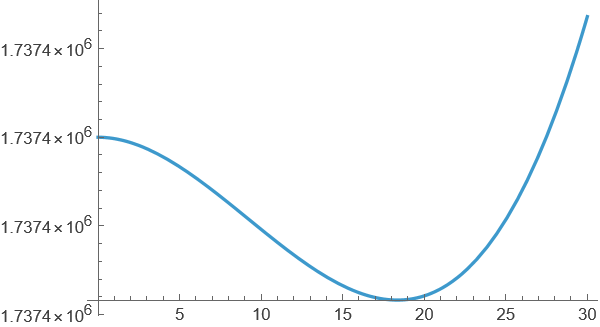
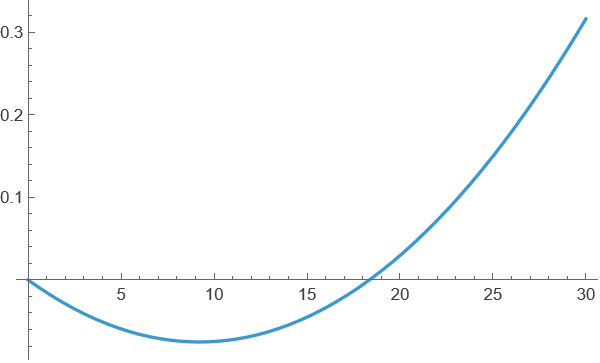
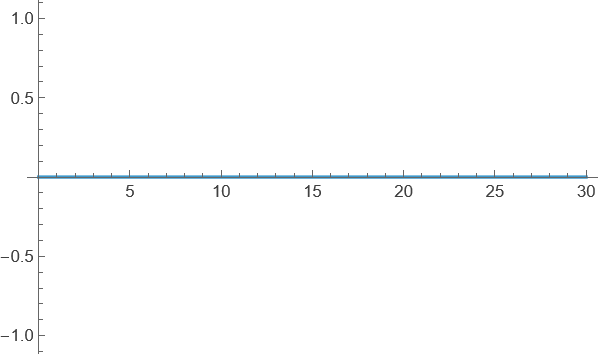
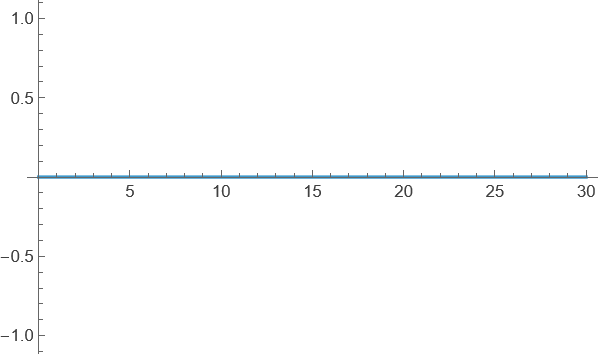
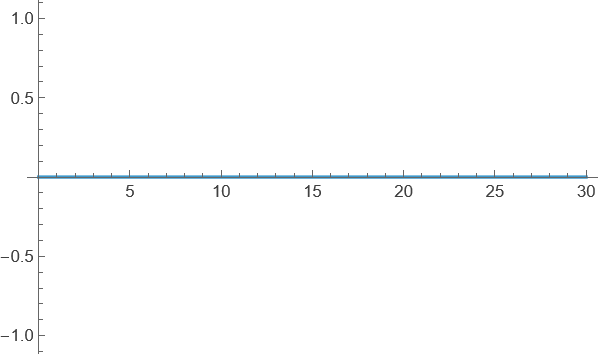
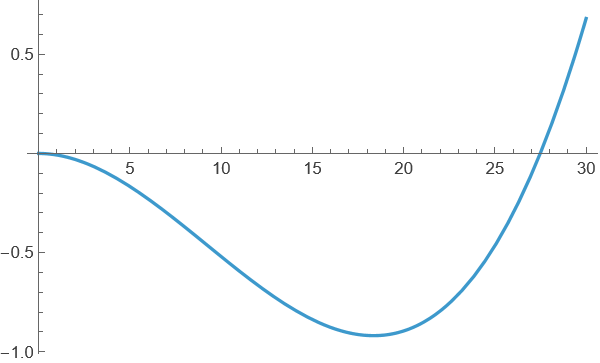

In [199]:
PLOT1 = Plot[rSolSC[t], {t, 0, tfin}] 
PLOT2 = Plot[rSCdotSol[t], {t, 0, tfin}] 
PLOT3 = Plot[ThetaAngSolSC[t], {t, 0, tfin}] 
PLOT4 = Plot[ThetaAngDotSolSC[t], {t, 0, tfin}] 
PLOT5 = Plot[vtSolSC[t], {t, 0, tfin}] 
PLOT6 = Plot[AltHnumSC[t], {t, 0, tfin}] 

The behavior shown is clearly consistent with intuitive expectations, that is, the rocket initially falls under the action of the gravitational force while its mass decreases at constant thrust. As thrust overcomes the weight of the vehicle, the accumulated negative vertical speed is reduced to zero, the rocket transits back at its initial position ($H=0$) and it starts a belated climb.  

In [209]:
rSolSC[12] - RadiusMoon 
MassRocket [311, 12]

-0.663454
4638.74

### <a class="anchor" id="4.2_Linear_Tangent_Steering_Laws"></a>  4.2 Linear-Tangent Steering Laws

[Back to Table of Contents](#Table_of_Contents) 

In this Section, we shall implement a model of the ascent of the Apollo ascent stage as described by Bennett. In order to be somewhat realistic, we shall adopt a linear-tangent steering law describing the thrusting program followed after ignition. Such steering laws represent a very important application of optimization techniques to propulsion (see, for instance, Miele (1962)). For simplicity, we shall use the linear-tangent steering law illustrated by Thomson (1986), at Eq. (8.3-9):

$$
\tan\phi_{\mathrm{th}}(t) = \Bigl(1 - {t\over T_{\mathrm{progr}} }\Bigr)\tan\phi_0\, ,
$$ 

where $t$ is the time from the beginning of thrusting, $T_{\mathrm{progr}}$ is the total time needed for the maneuver, and $\phi_0$ is the initial thrusting angle to the burnout horizontal. As is evident from the above equation, $\phi_{\mathrm{th}}(0) = \phi_0$, and $\phi_{\mathrm{th}}(T_{\mathrm{progr}}) = 0$. 

### <a class="anchor" id="4.2.1_Takeoff_at_a_thrusting_angle_equal_to"></a>  4.2.1 Takeoff at a thrusting angle equal to $\phi_0$

[Back to Table of Contents](#Table_of_Contents) 

In this first example, we shall assume a takeoff at the initial angle $\phi_{\mathrm{th}}(0) = \phi_0 = 40^\circ$. The orbit insertion time shall be $T_{\mathrm{progr}} = 436$ s (Bennett, p.~14).


In [219]:
ThrustPhi1[t_, phi0_, Tprogr_] = (ArcTan[(1 - (t/Tprogr)) Tan[phi0 Degree]]);

-Graphics-
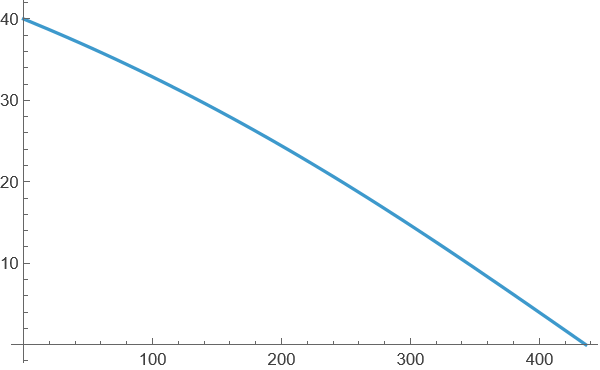

In [220]:
PLOTThrustPhi1 = Plot[ThrustPhi1[t, 40, 436] /Degree , {t, 0, 436}, PlotRange->All]

In [221]:
r0 = RadiusMoon ;
rdot0 = 0.0 ;
ThetaSC0 = 0.0;
ThetaAngSCdot0 = 0.0;

In [225]:
tfin = 436.0

436.

{0., {{rSC -> InterpolatingFunction[{{0., 436.}}, <>], 
 
>     ThetaAngSC -> InterpolatingFunction[{{0., 436.}}, <>]}}}
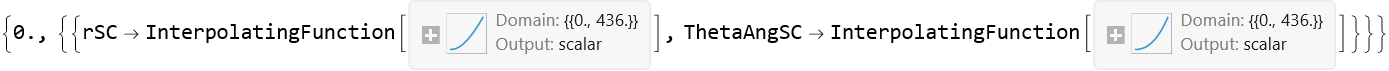

In [226]:
Timing[Thrust2BP = NDSolve[
                {rSC''[t] == (rSC[t] (ThetaAngSC'[t]^2)) - (kMoon/(rSC[t])^2) + (mdot[311] vexh [311]  /MassRocket [311, t]) Sin[ThrustPhi1[t, 40, 436]], 
                ThetaAngSC''[t]==-(2/rSC[t])rSC'[t]ThetaAngSC'[t] + (1/rSC[t])(mdot[311] vexh [311]  /MassRocket [311, t]) Cos[ThrustPhi1[t, 40, 436]], 
                rSC[0]==r0,rSC'[0]==rdot0,ThetaAngSC[0]==ThetaSC0,ThetaAngSC'[0]==ThetaAngSCdot0},
                {rSC,ThetaAngSC},{t,0,tfin},
                AccuracyGoal->13,PrecisionGoal->13,MaxSteps->∞, 
                Method -> {"StiffnessSwitching","NonstiffTest"->False}]]

In [227]:
rSolSC[t_] = Evaluate[rSC[t] /. Thrust2BP ][[1]];
rSCdotSol[t_] = Evaluate[rSC'[t] /. Thrust2BP ][[1]];
ThetaAngSolSC[t_] = Evaluate[ThetaAngSC[t] /. Thrust2BP ][[1]];
ThetaAngDotSolSC[t_] = Evaluate[ThetaAngSC'[t] /. Thrust2BP ][[1]];
vtSolSC[t_] = ThetaAngDotSolSC[t]rSolSC[t];
AltHnumSC[t_] = rSolSC[t] - RadiusMoon ;

-Graphics-
-Graphics-
-Graphics-
-Graphics-
-Graphics-
-Graphics-
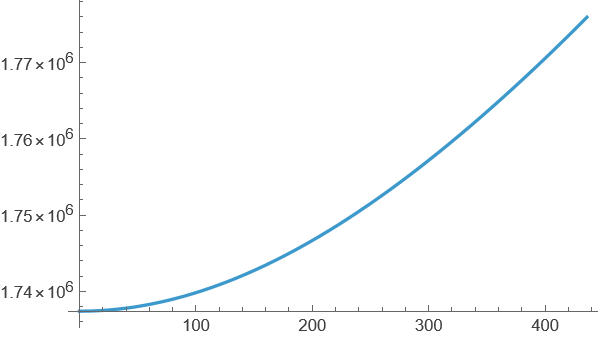
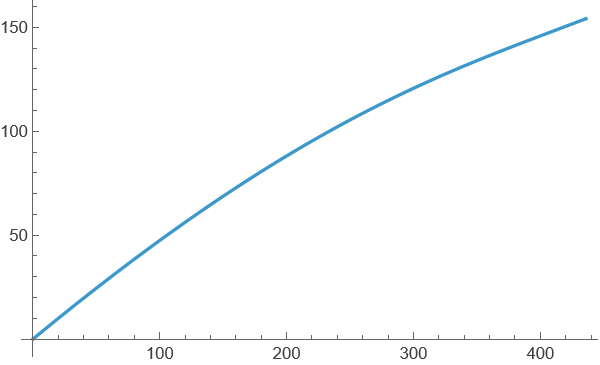
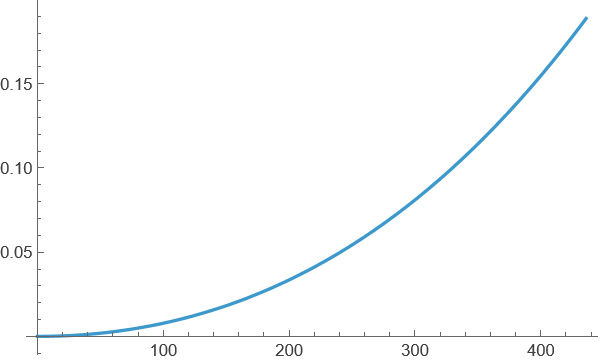
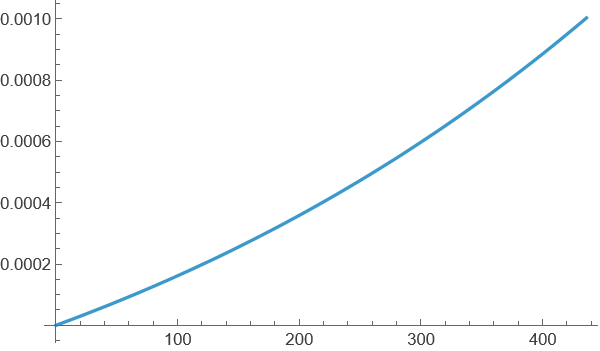
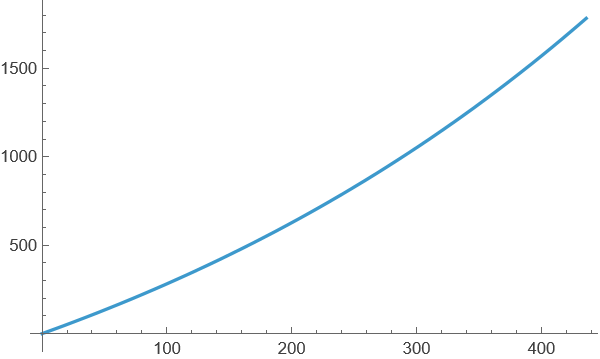
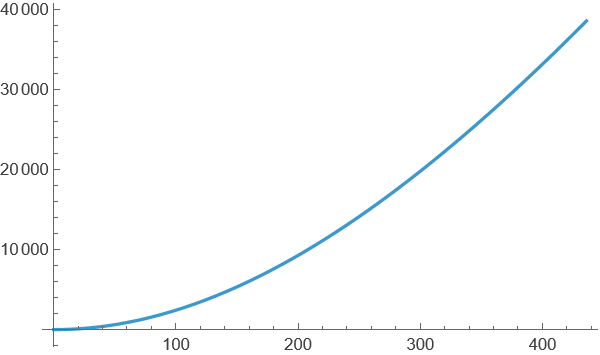

In [233]:
PLOT1 = Plot[rSolSC[t], {t, 0, tfin}] 
PLOT2 = Plot[rSCdotSol[t], {t, 0, tfin}] 
PLOT3 = Plot[ThetaAngSolSC[t], {t, 0, tfin}] 
PLOT4 = Plot[ThetaAngDotSolSC[t], {t, 0, tfin}] 
PLOT5 = Plot[vtSolSC[t], {t, 0, tfin}] 
PLOT6 = Plot[AltHnumSC[t], {t, 0, tfin}]

The state at orbit insertion is:

In [243]:
rSolSC[tfin]
rSCdotSol[tfin] 
ThetaAngSolSC[tfin]
ThetaAngDotSolSC[tfin]
vtSolSC[tfin] 
AltHnumSC[tfin] 

AltHnumSC[30] 
AltHnumSC[30] / ft

6
1.77595 10
154.158
0.188766
0.00100352
1782.2
38547.9
224.425
736.304

We shall now plot the trajectory by transforming to Cartesian coordinates and creating a parametric plot, here shown on the two different scales for clarity:

In [255]:
xSolSC[t_] = rSolSC[t] Cos[ThetaAngSolSC[t]];
ySolSC[t_] = rSolSC[t] Sin[ThetaAngSolSC[t]];

-Graphics-
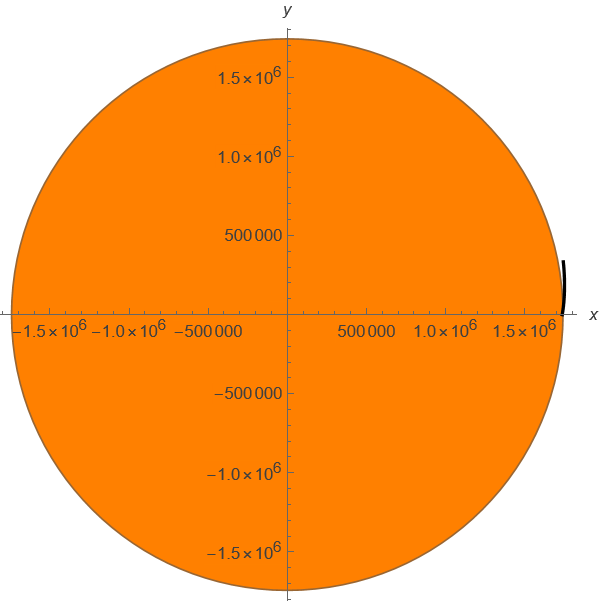

In [257]:
PLOTSCTraj1 = ParametricPlot[{xSolSC[t],ySolSC[t]},{t,0,tfin},
                              Axes->True,AxesLabel->{x,y},PlotStyle->Black, 
                              PlotRange -> {{-2000 10^3, 2000 10^3}, {-2000 10^3, 2000 10^3}}];

PLOTMoonEdge = Graphics[{Brown,Thick,Circle[{0,0}, RadiusMoon]} ,Axes->True,AxesLabel->{x,y}];
PLOTMoonDisk = Graphics[{Orange,Disk[{0,0}, RadiusMoon]}, PlotRange -> {{-2000 10^3, 2000 10^3}, {-2000 10^3, 2000 10^3}} ];
PLOTMoonAll = Show[PLOTMoonEdge, PLOTMoonDisk];

PlotNumerAll  =Show[PLOTMoonAll,PLOTSCTraj1]

-Graphics-
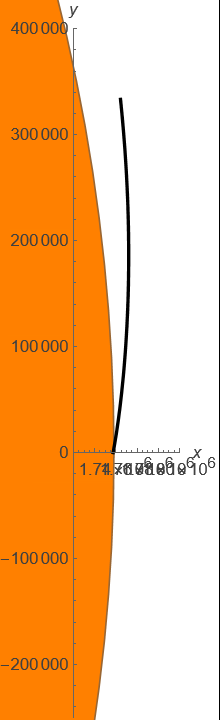

In [262]:
PLOTSCTraj2 = ParametricPlot[{xSolSC[t],ySolSC[t]},{t,0,436},
                              Axes->True,AxesLabel->{x,y},PlotStyle->Black, 
                              PlotRange -> {{1700 10^3, 1800 10^3}, {-250 10^3, 400 10^3}}];

PLOTMoonEdge = Graphics[{Brown,Thick,Circle[{0,0}, RadiusMoon]} ,Axes->True,AxesLabel->{x,y}];
PLOTMoonDisk = Graphics[{Orange,Disk[{0,0}, RadiusMoon]}, PlotRange -> {{1700 10^3, 1800 10^3}, {-250 10^3, 400 10^3}} ];
PLOTMoonAll = Show[PLOTMoonEdge, PLOTMoonDisk];

PlotNumerAll2  =Show[PLOTMoonAll,PLOTSCTraj2, PlotRange -> {{1700 10^3, 1800 10^3}, {-250 10^3, 400 10^3}}]

### <a class="anchor" id="4.2.2_Vertical_takeoff_to_a_linear_tangent_law"></a>  4.2.2 Vertical takeoff to a linear tangent law 

[Back to Table of Contents](#Table_of_Contents) 

In this final example, we shall include a phase of vertical climb lasting from $t=0$ till $t=t_{\mathrm{vert}}$ before commencing the thrusting program. Notice that the total thrusting time is now $t_{\mathrm{vert}} + T_{\mathrm{progr}} = 436$ s. 

The mathematical statement of a variable thrust angle is based on the use of the Heaviside function (see https://reference.wolfram.com/language/ref/HeavisideTheta.html for the Mathematica language implementation):

$$
\theta(t) = 
\begin{cases}
0, {\mathrm{if}}\, t <0\\
1, {\mathrm{if}}\, t \geq 0\, .
\end{cases}
$$

In [271]:
ThrustPhi2[t_, tvert_, phi0_, Tprogr_] =  (Pi/2)(HeavisideTheta [tvert -t]) + (HeavisideTheta [t-tvert]) ((ArcTan[(1 - ((HeavisideTheta [t-tvert])(t-tvert)/Tprogr)) Tan[phi0 Degree]]));

In [272]:
ThrustPhi2[9.9, 10, 40, 426] / Degree 

90.

-Graphics-
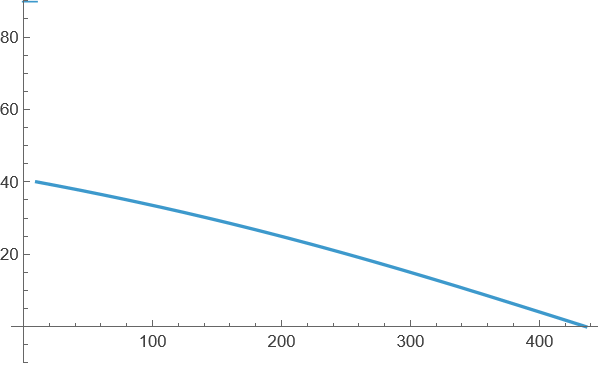

In [273]:
Plot[ThrustPhi2[t, 10, 40, 426] /Degree , {t, 0, 436}, PlotRange->{-10,90}]

In [274]:
r0 = RadiusMoon ;
rdot0 = 0.0 ;
ThetaSC0 = 0.0;
ThetaAngSCdot0 = 0.0;

In [278]:
tfin = 436.

436.

{0.03125, {{rSC -> InterpolatingFunction[{{0., 436.}}, <>], 
 
>     ThetaAngSC -> InterpolatingFunction[{{0., 436.}}, <>]}}}
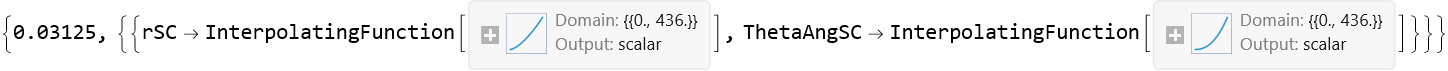

In [279]:
Timing[Thrust2BP = NDSolve[
         {rSC''[t] == (rSC[t] (ThetaAngSC'[t]^2)) - (kMoon/(rSC[t])^2) + (mdot[311] vexh [311]  /MassRocket [311, t]) Sin[ThrustPhi2[t, 10, 35, 426]], 
         ThetaAngSC''[t]==-(2/rSC[t])rSC'[t]ThetaAngSC'[t] + (1/rSC[t])(mdot[311] vexh [311]  /MassRocket [311, t]) Cos[ThrustPhi2[t, 10, 35, 426]], 
         rSC[0]==r0,rSC'[0]==rdot0,ThetaAngSC[0]==ThetaSC0,ThetaAngSC'[0]==ThetaAngSCdot0},
         {rSC,ThetaAngSC},{t,0,tfin},
         AccuracyGoal->13,PrecisionGoal->13,MaxSteps->∞, 
         Method -> {"StiffnessSwitching","NonstiffTest"->False}]]

In [280]:
rSolSC[t_] = Evaluate[rSC[t] /. Thrust2BP ][[1]];
rSCdotSol[t_] = Evaluate[rSC'[t] /. Thrust2BP ][[1]];
ThetaAngSolSC[t_] = Evaluate[ThetaAngSC[t] /. Thrust2BP ][[1]];
ThetaAngDotSolSC[t_] = Evaluate[ThetaAngSC'[t] /. Thrust2BP ][[1]];
vtSolSC[t_] = ThetaAngDotSolSC[t]rSolSC[t];
AltHnumSC[t_] = rSolSC[t] - RadiusMoon ;

-Graphics-
-Graphics-
-Graphics-
-Graphics-
-Graphics-
-Graphics-
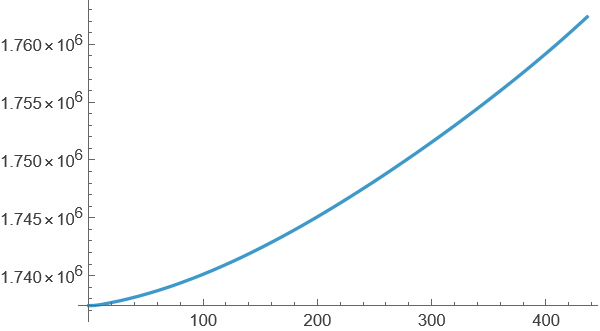
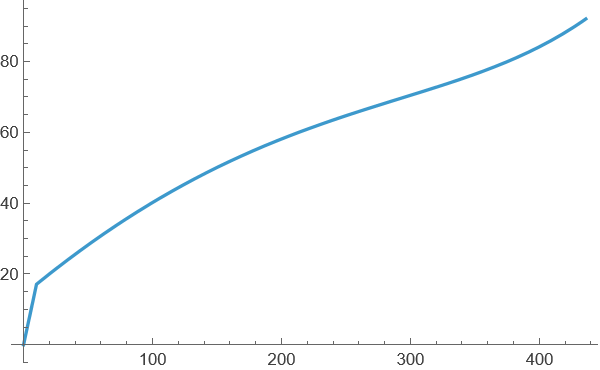
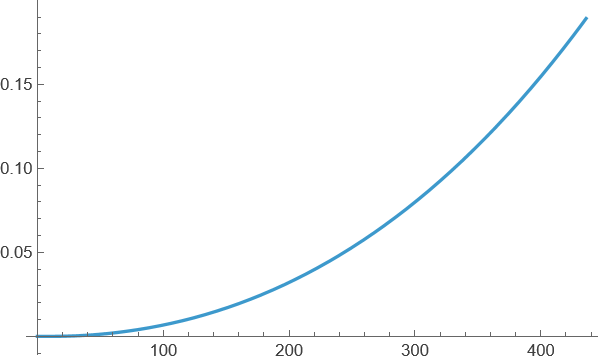
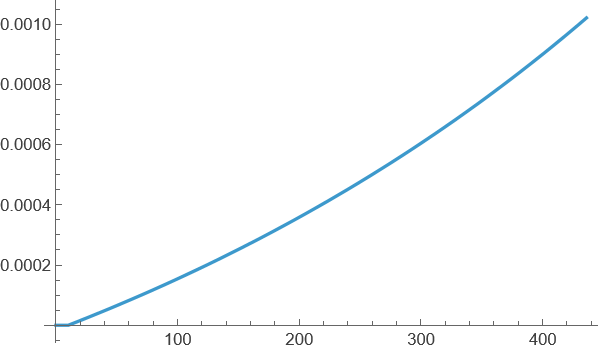
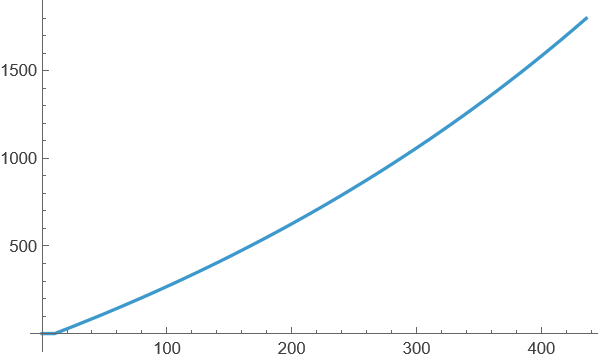
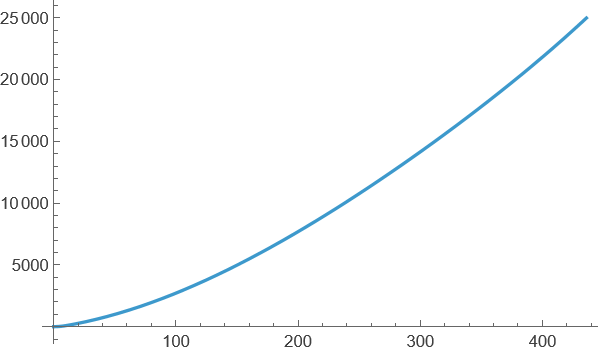

In [286]:
PLOT1 = Plot[rSolSC[t], {t, 0, tfin}] 
PLOT2 = Plot[rSCdotSol[t], {t, 0, tfin}] 
PLOT3 = Plot[ThetaAngSolSC[t], {t, 0, tfin}] 
PLOT4 = Plot[ThetaAngDotSolSC[t], {t, 0, tfin}] 
PLOT5 = Plot[vtSolSC[t], {t, 0, tfin}] 
PLOT6 = Plot[AltHnumSC[t], {t, 0, tfin}]

The vertical climb phase is evident from the results shown above. 

Evaluating the altitude at $t=30$ s allows us one more check with the existing record for Apollo $17$: 

In [296]:
AltHnumSC[30]
AltHnumSC[30] / ft 

484.179
1588.51

In [298]:
xSolSC[t_] = rSolSC[t] Cos[ThetaAngSolSC[t]];
ySolSC[t_] = rSolSC[t] Sin[ThetaAngSolSC[t]]; 

-Graphics-
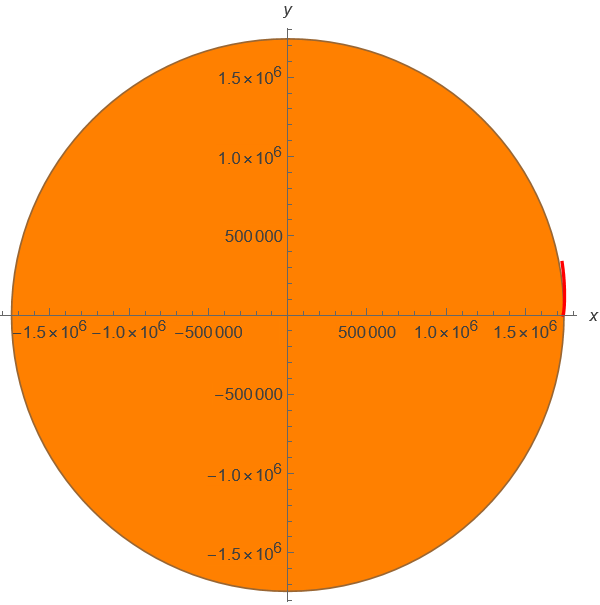

In [300]:
PLOTSCTraj1 = ParametricPlot[{xSolSC[t],ySolSC[t]},{t,0,tfin},Axes->True,AxesLabel->{x,y},PlotStyle->Red, PlotRange -> {{-2000 10^3, 2000 10^3}, {-2000 10^3, 2000 10^3}}];

PLOTMoonEdge = Graphics[{Brown,Thick,Circle[{0,0}, RadiusMoon]} ,Axes->True,AxesLabel->{x,y}];
PLOTMoonDisk = Graphics[{Orange,Disk[{0,0}, RadiusMoon]}, PlotRange -> {{-2000 10^3, 2000 10^3}, {-2000 10^3, 2000 10^3}} ];
PLOTMoonAll = Show[PLOTMoonEdge, PLOTMoonDisk];

PlotNumerAll  =Show[PLOTMoonAll,PLOTSCTraj1]

In [2129]:
Export["D:/OneDrive/Desktop/AE-401/Figures/TrajectoryPlot.pdf", PlotNumerAll] 

D:/OneDrive/Desktop/AE-401/Figures/TrajectoryPlot.pdf

-Graphics-
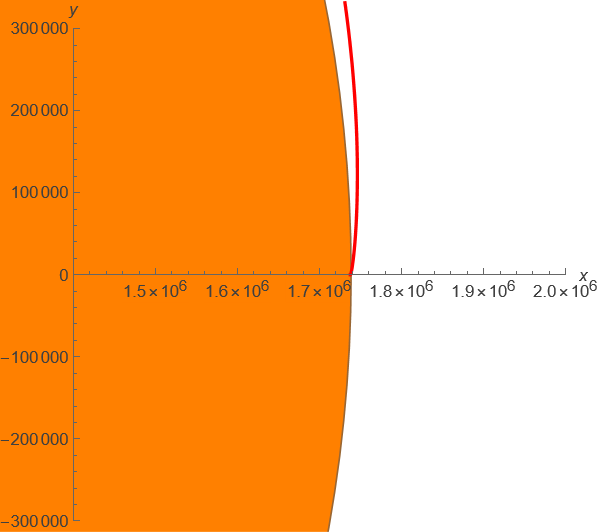

In [305]:
PLOTSCTraj2 = ParametricPlot[{xSolSC[t],ySolSC[t]},{t,0,tfin},Axes->True,AxesLabel->{x,y},PlotStyle->Red, PlotRange -> {{1400 10^3, 2000 10^3}, {-300 10^3, 300 10^3}}];

PLOTMoonEdge = Graphics[{Brown,Thick,Circle[{0,0}, RadiusMoon]} ,Axes->True,AxesLabel->{x,y}];
PLOTMoonDisk = Graphics[{Orange,Disk[{0,0}, RadiusMoon]}, PlotRange -> {{1400 10^3, 2000 10^3}, {-300 10^3, 300 10^3}} ];
PLOTMoonAll = Show[PLOTMoonEdge, PLOTMoonDisk];

PlotNumerAll2  =Show[PLOTMoonAll,PLOTSCTraj2, PlotRange -> {{1400 10^3, 2000 10^3}, {-300 10^3, 300 10^3}}] 

-Graphics-
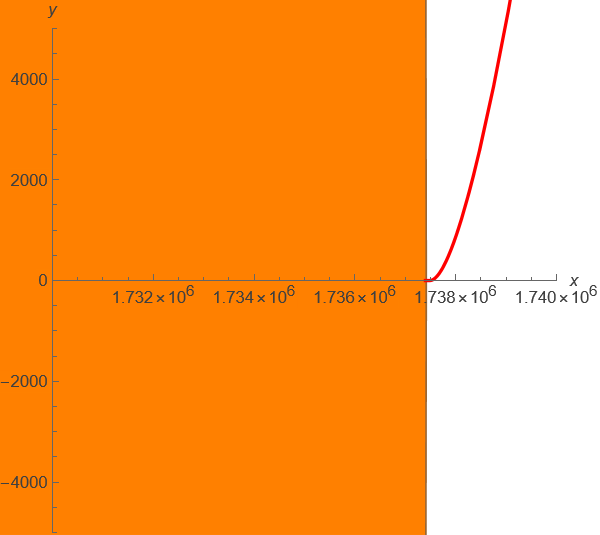

In [310]:
PLOTSCTraj2 = ParametricPlot[{xSolSC[t],ySolSC[t]},{t,0,tfin},Axes->True,AxesLabel->{x,y},PlotStyle->Red, PlotRange -> {{1730 10^3, 1740 10^3}, {-5 10^3, 5 10^3}}];

PLOTMoonEdge = Graphics[{Brown,Thick,Circle[{0,0}, RadiusMoon]} ,Axes->True,AxesLabel->{x,y}];
PLOTMoonDisk = Graphics[{Orange,Disk[{0,0}, RadiusMoon]}, PlotRange -> {{1736 10^3, 1740 10^3}, {-5 10^3, 5 10^3}} ];
PLOTMoonAll = Show[PLOTMoonEdge, PLOTMoonDisk];

PlotNumerAll2  =Show[PLOTMoonAll,PLOTSCTraj2, PlotRange -> {{1730 10^3, 1740 10^3}, {-5 10^3, 5 10^3}}] 

The final state at orbit insertion is:

In [319]:
rSolSC[tfin]
rSCdotSol[tfin] 

ThetaAngSolSC[tfin]
ThetaAngDotSolSC[tfin]
vtSolSC[tfin] 
AltHnumSC[tfin] 

Sqrt[(((rSCdotSol[tfin])^2) + ((vtSolSC[tfin])^2))] 

AltHnumSC[30] 

rSCdotSol[tfin] / ft
AltHnumSC[tfin]  / ft
Sqrt[(((rSCdotSol[tfin])^2) + ((vtSolSC[tfin])^2))] / ft 

ArcTan[rSCdotSol[tfin]/vtSolSC[tfin]] / Degree

6
1.76238 10
92.028
0.189215
0.00102047
1798.45
24980.
1800.8
484.179
301.929
81955.4
5908.14
2.92931

The final orbit is given by the following quantities:

In [335]:
lSAM = rSolSC[tfin] vtSolSC[tfin] 

EnergySpecAM = (1/2)(((rSCdotSol[tfin])^2) + ((vtSolSC[tfin])^2)) - (kMoon/rSolSC[tfin]) 

EccentricityAM = Sqrt[1 + (2 EnergySpecAM ((lSAM)^2) /(kMoon^2))] 

SMAAM = - kMoon / (2 EnergySpecAM) 

rpAM = SMAAM (1 - EccentricityAM) 

raAM = SMAAM (1 + EccentricityAM) 

RadiusMoon 

TPeriod = (2 Pi /Sqrt[kMoon]) (SMAAM^(3/2))

9
3.16955 10
           6
-1.16165 10
0.172726
          6
2.11116 10
          6
1.74651 10
          6
2.47582 10
         6
1.7374 10
8702.59

The trajectory following engine shutdown can be obtained by direct integration as usual:

In [347]:
r0 = rSolSC[tfin] 
rdot0 = rSCdotSol[tfin]  
ThetaSC0 = ThetaAngSolSC[tfin] 
ThetaAngSCdot0 = ThetaAngDotSolSC[tfin] 

6
1.76238 10
92.028
0.189215
0.00102047

In [351]:
tfinOrb = 8500 

8500

{0., {{rSC -> InterpolatingFunction[{{0., 8500.}}, <>], 
 
>     ThetaAngSC -> InterpolatingFunction[{{0., 8500.}}, <>]}}}
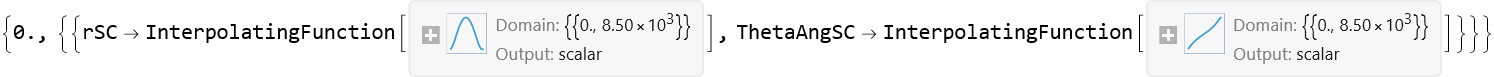

In [352]:
Timing[Thrust2BPOrb = NDSolve[
{rSC''[t] == (rSC[t] (ThetaAngSC'[t]^2)) - (kMoon/(rSC[t])^2), 
ThetaAngSC''[t]==-(2/rSC[t])rSC'[t]ThetaAngSC'[t], 
rSC[0]==r0,rSC'[0]==rdot0,ThetaAngSC[0]==ThetaSC0,ThetaAngSC'[0]==ThetaAngSCdot0},
{rSC,ThetaAngSC},{t,0,tfinOrb},
AccuracyGoal->13,PrecisionGoal->13,MaxSteps->∞, 
Method -> {"StiffnessSwitching","NonstiffTest"->False}]]

In [353]:
rSolSCOrb[t_] = Evaluate[rSC[t] /. Thrust2BPOrb ][[1]];
rSCdotSolOrb[t_] = Evaluate[rSC'[t] /. Thrust2BPOrb ][[1]];
ThetaAngSolSCOrb[t_] = Evaluate[ThetaAngSC[t] /. Thrust2BPOrb ][[1]];
ThetaAngDotSolSCOrb[t_] = Evaluate[ThetaAngSC'[t] /. Thrust2BPOrb ][[1]];
vtSolSCOrb[t_] = ThetaAngDotSolSCOrb[t] rSolSCOrb[t];
AltHnumSCOrb[t_] = rSolSCOrb[t] - RadiusMoon ;

-Graphics-
-Graphics-
-Graphics-
-Graphics-
-Graphics-
-Graphics-
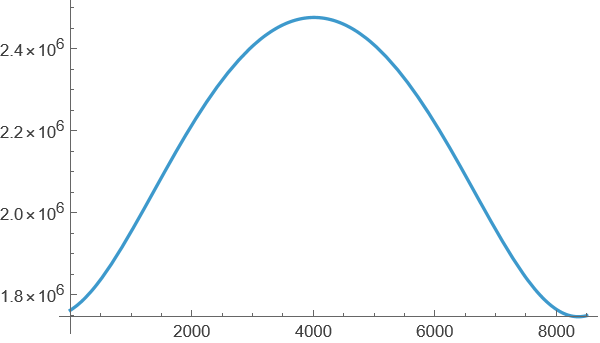
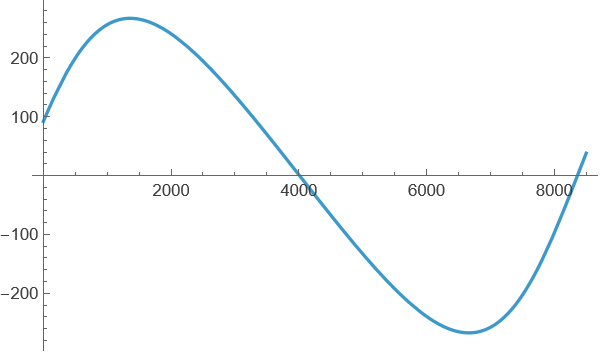
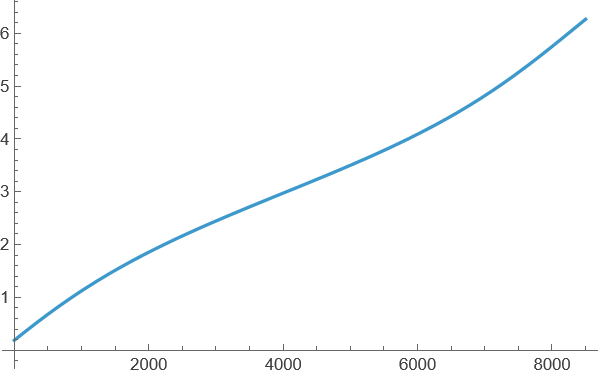
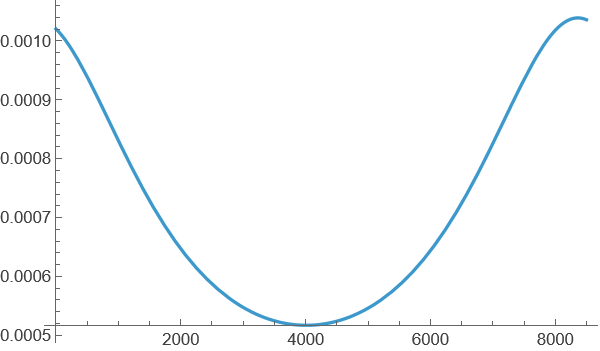
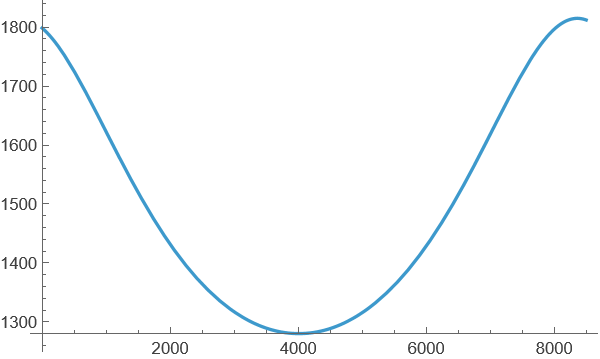
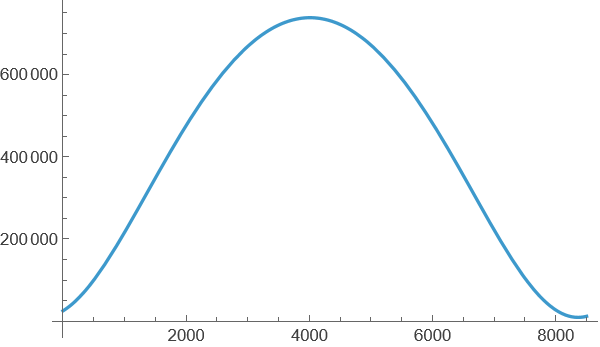

In [359]:
PLOT7 = Plot[rSolSCOrb[t], {t, 0, tfinOrb}] 
PLOT8 = Plot[rSCdotSolOrb[t], {t, 0, tfinOrb}] 
PLOT9 = Plot[ThetaAngSolSCOrb[t], {t, 0, tfinOrb}] 
PLOT10 = Plot[ThetaAngDotSolSCOrb[t], {t, 0, tfinOrb}] 
PLOT11 = Plot[vtSolSCOrb[t], {t, 0, tfinOrb}] 
PLOT12 = Plot[AltHnumSCOrb[t], {t, 0, tfinOrb}]

In [365]:
xSolSCOrb[t_] = rSolSCOrb[t] Cos[ThetaAngSolSCOrb[t]];
ySolSCOrb[t_] = rSolSCOrb[t] Sin[ThetaAngSolSCOrb[t]]; 

-Graphics-
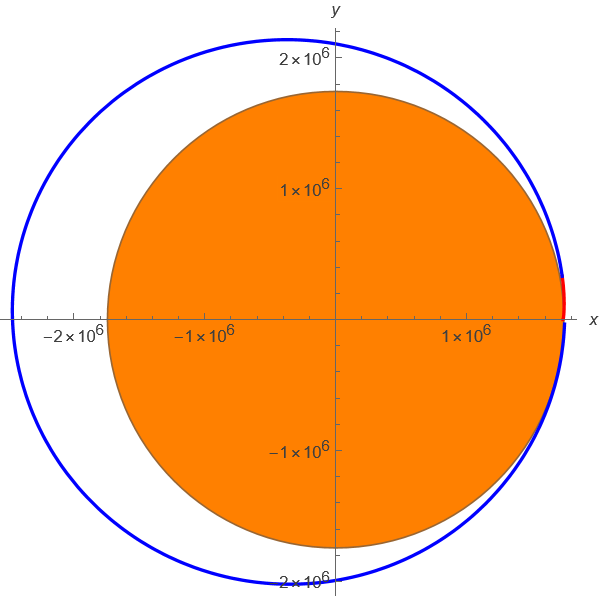

In [367]:
PLOTSCTraj1Orb = ParametricPlot[{xSolSCOrb[t],ySolSCOrb[t]},{t,0,tfinOrb},Axes->True,AxesLabel->{x,y},PlotStyle->Blue, PlotRange -> {{-2000 10^3, 2000 10^3}, {-2000 10^3, 2000 10^3}}];

PLOTMoonEdge = Graphics[{Brown,Thick,Circle[{0,0}, RadiusMoon]} ,Axes->True,AxesLabel->{x,y}];
PLOTMoonDisk = Graphics[{Orange,Disk[{0,0}, RadiusMoon]}, PlotRange -> {{-2000 10^3, 2000 10^3}, {-2000 10^3, 2000 10^3}} ];
PLOTMoonAll = Show[PLOTMoonEdge, PLOTMoonDisk];

PlotNumerAll  =Show[PLOTMoonAll, PLOTSCTraj1, PLOTSCTraj1Orb]

-Graphics-
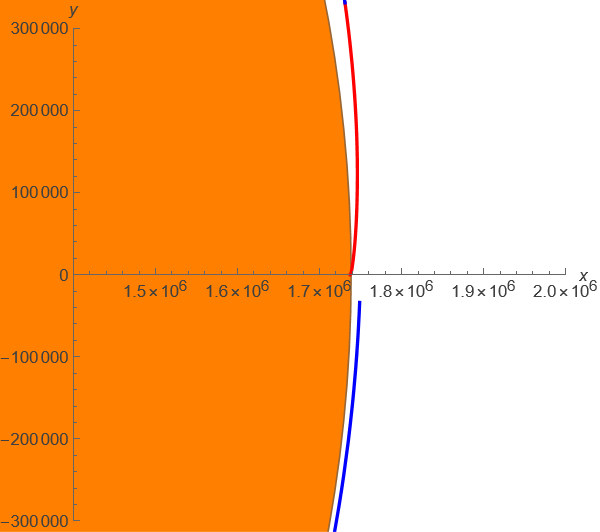

In [372]:
PLOTSCTraj2Orb = ParametricPlot[{xSolSCOrb[t],ySolSCOrb[t]},{t,0,tfinOrb},Axes->True,AxesLabel->{x,y},PlotStyle->Blue, PlotRange -> {{1400 10^3, 2000 10^3}, {-300 10^3, 300 10^3}}];

PLOTSCTraj2 = ParametricPlot[{xSolSC[t],ySolSC[t]},{t,0,tfin},Axes->True,AxesLabel->{x,y},PlotStyle->Red, PlotRange -> {{1400 10^3, 2000 10^3}, {-300 10^3, 300 10^3}}];

PLOTMoonEdge = Graphics[{Brown,Thick,Circle[{0,0}, RadiusMoon]} ,Axes->True,AxesLabel->{x,y}];
PLOTMoonDisk = Graphics[{Orange,Disk[{0,0}, RadiusMoon]}, PlotRange -> {{1400 10^3, 2000 10^3}, {-300 10^3, 300 10^3}} ];
PLOTMoonAll = Show[PLOTMoonEdge, PLOTMoonDisk];

PlotNumerAll2  =Show[PLOTMoonAll,PLOTSCTraj2, PLOTSCTraj2Orb, PlotRange -> {{1400 10^3, 2000 10^3}, {-300 10^3, 300 10^3}}] 

In [378]:
rSolSCOrb[7360]

6
1.87155 10

In [379]:
rSolSCOrb[tfinOrb]

6
1.74914 10

In [380]:
(*Alter the fraction 8/9 if an error message appears. Check the result by using PLOT7. *)

rpNum = FindMinimum[Evaluate[rSC[t] /. Thrust2BPOrb ][[1]], {t, (10/11) tfinOrb, tfinOrb}]

6
{1.74651 10 , {t -> 8362.3}}

In [382]:
(*Time at perilune*)

rpNum[[1]]
rpNum[[2,1,2]]

6
1.74651 10
8362.3

In [385]:
(*argument of the periapsis*)

ThetaAngSolSCOrb[rpNum[[2,1,2]]]

6.12093

In [387]:
(*Range from takeoff point at orbit insertion, in m*)
ThetaSC0 RadiusMoon
ThetaSC0 / Degree

328743.
10.8412

## <a class="anchor" id="5_Questions"></a> 5. Questions  

[Back to Table of Contents](#Table_of_Contents) 

Extract a random burn-time by replacing the figures 12345 by the last $5$ digits of your cell phone number:

In [394]:
SeedRandom[59786]; RandomReal[{438-17, 438+17}]

448.095

**1.** Repeat the above calculations shown in Sec. 4.2.2 with $t=t_{\mathrm{vert}} = 10$ s and $T_{\mathrm{progr}}$ equal to the value you generated randomly. 

In [399]:
ThrustPhi2[9.9, 10, 40, 448.095] / Degree

90.

-Graphics-
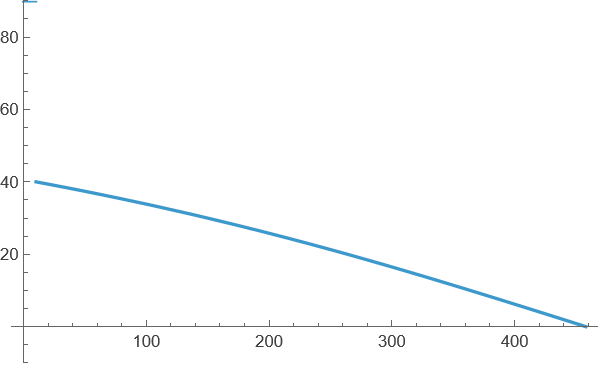

In [400]:
Plot[ThrustPhi2[t, 10, 40, 448.095] /Degree , {t, 0, 458.095}, PlotRange->{-10,90}]

**2.** Obtain plots of all quantities that provide the final state at orbit insertion $t=t_{\mathrm{fin}}$ as functions of $\phi_{\mathrm{th}}(0)$. These must include $r$, $\dot{r}$, $\theta$, $\dot{\theta}$, $v_t$, $|{\mathbf{v}}|$ and $H$. 

In [405]:
r0 = RadiusMoon 
rdot0 = 0.0 
ThetaSC0 = 0.0
ThetaAngSCdot0 = 0.0

6
1.7374 10
0.
0.
0.

In [409]:
tfin=458.095

458.095

{0.03125, {{rSC -> InterpolatingFunction[{{0., 458.095}}, <>], 
 
>     ThetaAngSC -> InterpolatingFunction[{{0., 458.095}}, <>]}}}
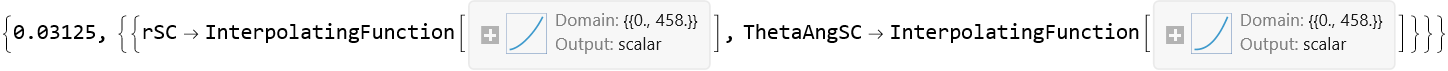

In [410]:
Timing[Thrust2BP = NDSolve[{rSC''[t] == (rSC[t] (ThetaAngSC'[t]^2)) - (kMoon/(rSC[t])^2) + (mdot[311] vexh [311]  /MassRocket [311, t]) Sin[ThrustPhi2[t, 10, 35, 448.095]], 
                            ThetaAngSC''[t]==-(2/rSC[t])rSC'[t]ThetaAngSC'[t] + (1/rSC[t])(mdot[311] vexh [311]  /MassRocket [311, t]) Cos[ThrustPhi2[t, 10, 35, 448.095]], 
                            rSC[0]==r0,rSC'[0]==rdot0,ThetaAngSC[0]==ThetaSC0,ThetaAngSC'[0]==ThetaAngSCdot0},
                            {rSC,ThetaAngSC},{t,0,tfin},AccuracyGoal->13,PrecisionGoal->13,MaxSteps->∞, 
                            Method -> {"StiffnessSwitching","NonstiffTest"->False}]]

In [411]:
rSolSC[t_] = Evaluate[rSC[t] /. Thrust2BP ][[1]];
rSCdotSol[t_] = Evaluate[rSC'[t] /. Thrust2BP ][[1]];
ThetaAngSolSC[t_] = Evaluate[ThetaAngSC[t] /. Thrust2BP ][[1]];
ThetaAngDotSolSC[t_] = Evaluate[ThetaAngSC'[t] /. Thrust2BP ][[1]];
vtSolSC[t_] = ThetaAngDotSolSC[t]rSolSC[t];
AltHnumSC[t_] = rSolSC[t] - RadiusMoon ;

-Graphics-
-Graphics-
-Graphics-
-Graphics-
-Graphics-
-Graphics-
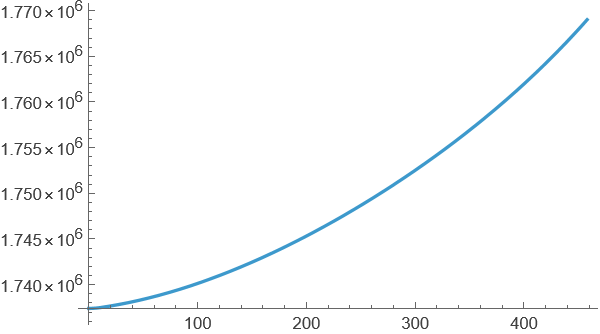
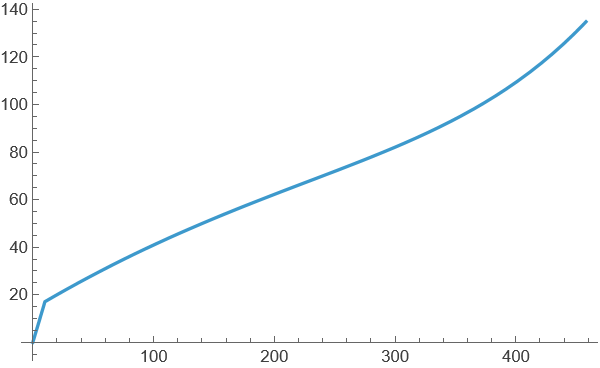
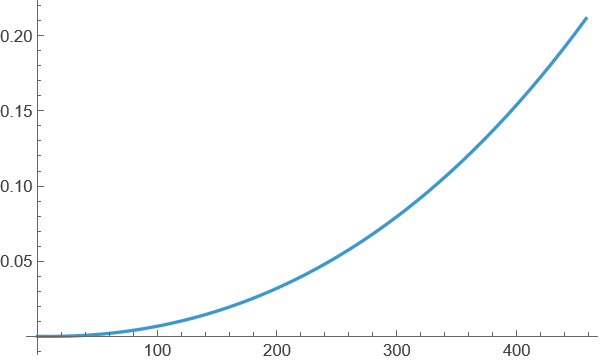
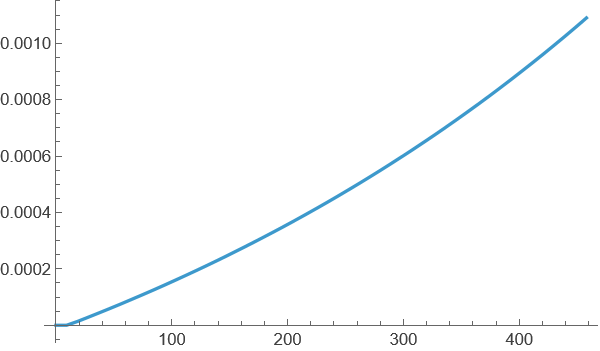
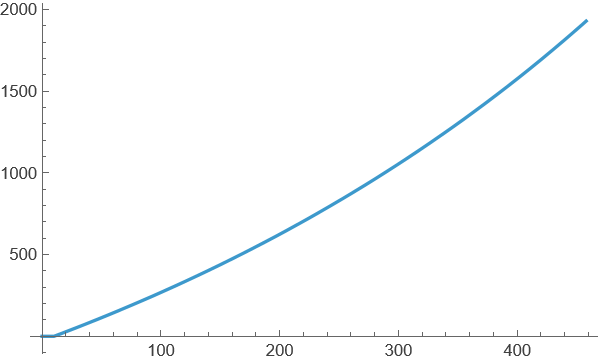
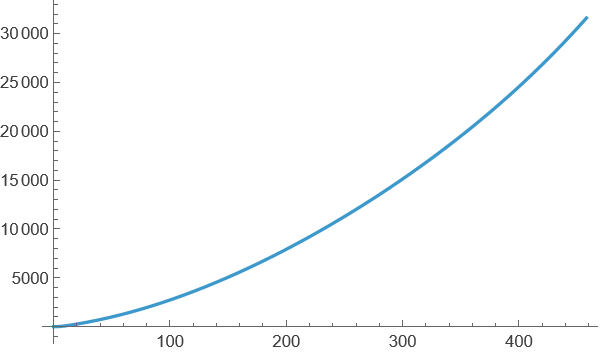

In [417]:
PLOT1 = Plot[rSolSC[t], {t, 0, tfin}] 
PLOT2 = Plot[rSCdotSol[t], {t, 0, tfin}] 
PLOT3 = Plot[ThetaAngSolSC[t], {t, 0, tfin}] 
PLOT4 = Plot[ThetaAngDotSolSC[t], {t, 0, tfin}] 
PLOT5 = Plot[vtSolSC[t], {t, 0, tfin}] 
PLOT6 = Plot[AltHnumSC[t], {t, 0, tfin}]

In [2139]:
Export["D:/OneDrive/Desktop/AE-401/Figures/RadiusPlot.pdf", PLOT1] 

D:/OneDrive/Desktop/AE-401/Figures/RadiusPlot.pdf

In [423]:
AltHnumSC[30]
AltHnumSC[30] / ft 

484.385
1589.19

In [425]:
xSolSC[t_] = rSolSC[t] Cos[ThetaAngSolSC[t]];
ySolSC[t_] = rSolSC[t] Sin[ThetaAngSolSC[t]]; 

-Graphics-
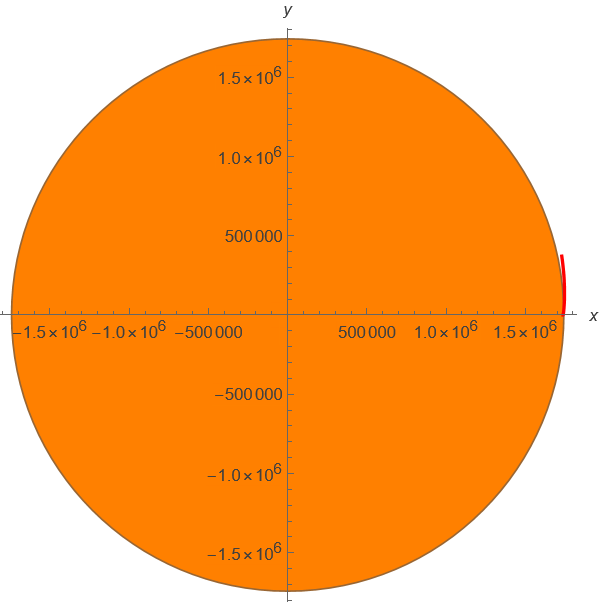

In [427]:
PLOTSCTraj1 = ParametricPlot[{xSolSC[t],ySolSC[t]},{t,0,tfin},Axes->True,AxesLabel->{x,y},PlotStyle->Red, PlotRange -> {{-2000 10^3, 2000 10^3}, {-2000 10^3, 2000 10^3}}];

PLOTMoonEdge = Graphics[{Brown,Thick,Circle[{0,0}, RadiusMoon]} ,Axes->True,AxesLabel->{x,y}];
PLOTMoonDisk = Graphics[{Orange,Disk[{0,0}, RadiusMoon]}, PlotRange -> {{-2000 10^3, 2000 10^3}, {-2000 10^3, 2000 10^3}} ];
PLOTMoonAll = Show[PLOTMoonEdge, PLOTMoonDisk];

PlotNumerAll  =Show[PLOTMoonAll,PLOTSCTraj1]

In [2149]:
Export["D:/OneDrive/Desktop/AE-401/Figures/TrajectoryPlot.pdf", PlotNumerAll] 

D:/OneDrive/Desktop/AE-401/Figures/TrajectoryPlot.pdf

-Graphics-
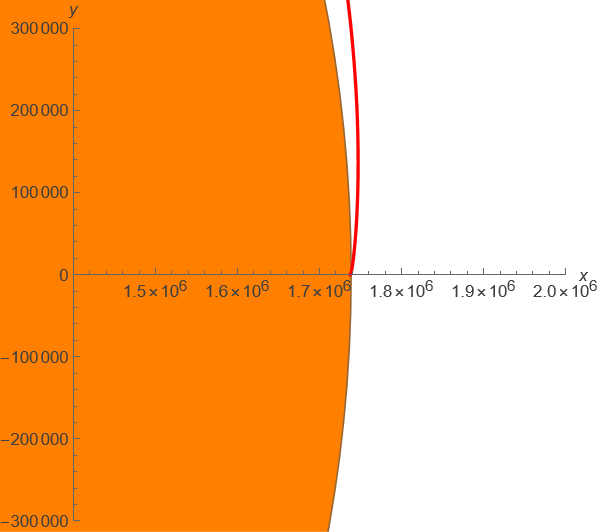

In [432]:
PLOTSCTraj2 = ParametricPlot[{xSolSC[t],ySolSC[t]},{t,0,tfin},Axes->True,AxesLabel->{x,y},PlotStyle->Red, PlotRange -> {{1400 10^3, 2000 10^3}, {-300 10^3, 300 10^3}}];

PLOTMoonEdge = Graphics[{Brown,Thick,Circle[{0,0}, RadiusMoon]} ,Axes->True,AxesLabel->{x,y}];
PLOTMoonDisk = Graphics[{Orange,Disk[{0,0}, RadiusMoon]}, PlotRange -> {{1400 10^3, 2000 10^3}, {-300 10^3, 300 10^3}} ];
PLOTMoonAll = Show[PLOTMoonEdge, PLOTMoonDisk];

PlotNumerAll2  =Show[PLOTMoonAll,PLOTSCTraj2, PlotRange -> {{1400 10^3, 2000 10^3}, {-300 10^3, 300 10^3}}] 

-Graphics-
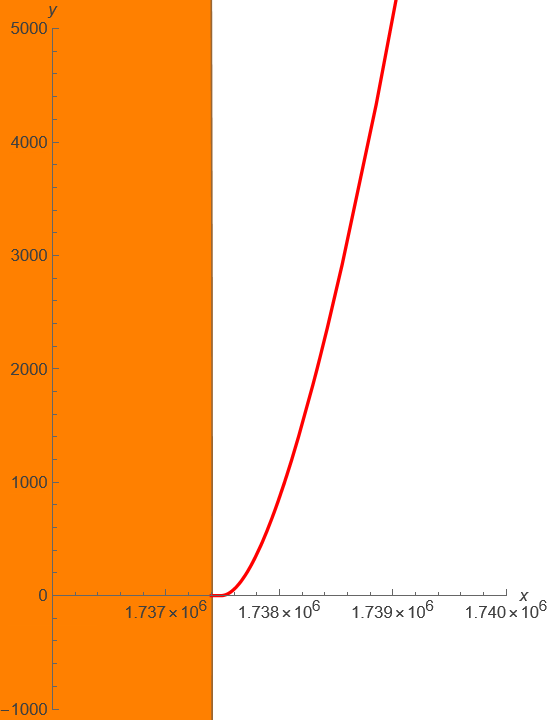

In [437]:
PLOTSCTraj2 = ParametricPlot[{xSolSC[t],ySolSC[t]},{t,0,tfin},Axes->True,AxesLabel->{x,y},PlotStyle->Red, PlotRange -> {{1736 10^3, 1740 10^3}, {-10^3, 5 10^3}}];

PLOTMoonEdge = Graphics[{Brown,Thick,Circle[{0,0}, RadiusMoon]} ,Axes->True,AxesLabel->{x,y}];
PLOTMoonDisk = Graphics[{Orange,Disk[{0,0}, RadiusMoon]}, PlotRange -> {{1736 10^3, 1740 10^3}, {-10^3, 5 10^3}} ];
PLOTMoonAll = Show[PLOTMoonEdge, PLOTMoonDisk];

PlotNumerAll2  =Show[PLOTMoonAll,PLOTSCTraj2, PlotRange -> {{1736 10^3, 1740 10^3}, {-10^3, 5 10^3}}] 

The final state of orbit insertion

In [446]:
rSolSC[tfin]
rSCdotSol[tfin] 

ThetaAngSolSC[tfin]
ThetaAngDotSolSC[tfin]
vtSolSC[tfin] 
AltHnumSC[tfin] 

Sqrt[(((rSCdotSol[tfin])^2) + ((vtSolSC[tfin])^2))] 

AltHnumSC[30] 

rSCdotSol[tfin] / ft
AltHnumSC[tfin]  / ft
Sqrt[(((rSCdotSol[tfin])^2) + ((vtSolSC[tfin])^2))] / ft 

ArcTan[rSCdotSol[tfin]/vtSolSC[tfin]] / Degree

6
1.76901 10
134.768
0.211468
0.00108999
1928.2
31607.6
1932.9
484.385
442.152
103700.
6341.55
3.99808

**3.** Obtain plots of all orbital elements at orbit insertion $t=t_{\mathrm{fin}}$ as functions of $\phi_{\mathrm{th}}(0)$. These must include $r_p$, $r_a$, $a$, $e$, $\omega$ (argument of the periapsis), and $T_P$ (peroid of revolution).  

In [1296]:
phi0list = Range[1, 70, 0.1];
tfin

458.095

In [1302]:
Thrust2BPphi0List = {};

In [1307]:
Do[S = NDSolve[{rSC''[t] == (rSC[t] (ThetaAngSC'[t]^2)) - (kMoon/(rSC[t]^2)) +(mdot[311] vexh[311] / MassRocket[311, t]) *Sin[ ThrustPhi2[t, 10, phi0, (tfin-10)] ],
                ThetaAngSC''[t] == -(2/rSC[t]) rSC'[t] ThetaAngSC'[t] +(1/rSC[t]) (mdot[311] vexh[311] / MassRocket[311, t]) *Cos[ ThrustPhi2[t, 10, phi0, (tfin-10)] ],
                rSC[0] == r0, rSC'[0] == rdot0,ThetaAngSC[0] == ThetaSC0, ThetaAngSC'[0] == ThetaAngSCdot0},
                {rSC, ThetaAngSC}, {t, 0, tfin},
                AccuracyGoal -> 13, PrecisionGoal -> 13, MaxSteps -> Infinity, Method -> {"StiffnessSwitching", "NonstiffTest" -> False}];
AppendTo[Thrust2BPphi0List, S];, {phi0, phi0list}]

Now, we extract orbital-element values at t = tfin for each stored solution

In [1316]:
lSAMphi0List = {};
EnergySpecAMphi0List = {};
EccentricityAMphi0List = {};
SMAAMphi0List = {};
rpAMphi0List = {};
raAMphi0List = {};
TPeriodphi0List = {};
APAMphi0List = {};

In [1830]:
Do[Apple = Thrust2BPphi0List[[i]];

  rFinal = (rSC[tfin] /. Apple[[1]]);
  rdotFinal = (rSC'[tfin] /. Apple[[1]]);
  thetaFinal = (ThetaAngSC[tfin] /. Apple[[1]]);
  thetadotFinal = (ThetaAngSC'[tfin] /. Apple[[1]]);

  vtFinal = rFinal * thetadotFinal;
  lSAMval = rFinal * vtFinal;

  EnergySpecVal = ((1/2) (rdotFinal^2 + vtFinal^2)) - (kMoon/rFinal);

  EccentricityVal = Sqrt[1 + ((2 *EnergySpecVal* (lSAMval^2))/(kMoon^2))];
  SMAVal = -kMoon/(2 EnergySpecVal);
  rpVal = SMAVal (1 - EccentricityVal);
  raVal = SMAVal (1 + EccentricityVal);
  TPeriodVal = (2 Pi/Sqrt[kMoon])*(SMAVal^(3/2));
(*the formula for argument of periapsis was retrieved from wikipedia :https://en.wikipedia.org/wiki/Argument_of_periapsis 
and I found the eccentricity vector at Bate, Mueller, White : Fundamentals of Astrodynamics(Section 1.5.4)*)
  xSC = rFinal Cos[thetaFinal]; 
  ySC = rFinal Sin[thetaFinal]; 
  ex0 = ((rdotFinal*Sin[thetaFinal]+rFinal*Cos[thetaFinal]*thetadotFinal)*lSAMval)/kMoon - xSC/rFinal; 
  ey0 = -((rdotFinal*Cos[thetaFinal]-rFinal*Sin[thetaFinal]*thetadotFinal)*lSAMval)/kMoon - ySC/rFinal; 
 
  APAMVal= ArcTan[ex0, ey0];
  (* Appending all values to their lists using AppendTo*)
  AppendTo[lSAMphi0List, lSAMval];
  AppendTo[EnergySpecAMphi0List, EnergySpecVal];
  AppendTo[EccentricityAMphi0List, EccentricityVal];
  AppendTo[SMAAMphi0List, SMAVal];
  AppendTo[rpAMphi0List, rpVal];
  AppendTo[raAMphi0List, raVal];
  AppendTo[TPeriodphi0List, TPeriodVal];
  AppendTo[APAMphi0List, APAMVal];
,{i, 1, Length[Thrust2BPphi0List]}];

In [1892]:
Print["rFinal = ", rFinal];
Print["rdotFinal = ", rdotFinal];
Print["vtFinal = ", vtFinal];
Print["kMoon/rFinal = ", kMoon/rFinal];
Print["Energy = ", (1/2)(rdotFinal^2 + vtFinal^2) - kMoon/rFinal];
APAMphi0List/ Degree

                   6
rFinal = 1.92919 10
rdotFinal = 770.88
vtFinal = 1321.53
                         6
kMoon/rFinal = 2.54246 10
                    6
Energy = -1.37211 10


{28.4107, 28.3758, 28.3409, 28.3059, 28.2708, 28.2355, 28.2004, 28.1652, 28.1299, 
 
>   28.0945, 28.0627, 28.0275, 27.9915, 27.9557, 27.9165, 27.8806, 27.8448, 27.8088, 
 
>   27.7728, 27.7381, 27.7004, 27.6641, 27.6276, 27.5912, 27.5547, 27.518, 27.4846, 
 
>   27.4445, 27.4076, 27.3707, 27.3336, 27.2964, 27.2592, 27.2218, 27.1845, 27.147, 
 
>   27.1094, 27.0717, 27.0338, 26.996, 26.9581, 26.9199, 26.8818, 26.8436, 26.8051, 
 
>   26.7668, 26.7282, 26.6896, 26.6507, 26.6119, 26.573, 26.5339, 26.4948, 26.4573, 
 
>   26.4161, 26.3766, 26.337, 26.2973, 26.2575, 26.2176, 26.1795, 26.1374, 26.0971, 
 
>   26.0568, 26.0163, 25.9757, 25.935, 25.8942, 25.8532, 25.8121, 25.7709, 25.7296, 
 
>   25.6881, 25.6465, 25.6047, 25.563, 25.5211, 25.4789, 25.4392, 25.3945, 25.352, 
 
>   25.3095, 25.2667, 25.2239, 25.1809, 25.1378, 25.0945, 25.051, 25.0075, 24.9637, 
 
>   24.9198, 24.8758, 24.8317, 24.7873, 24.7428, 24.6976, 24.6527, 24.6109, 24.5626, 
 
>   24.5173, 24.4718, 24.4262, 24.3804, 24.3344, 24.2883, 24.242, 24.1955, 24.1489, 
 
>   24.102, 24.0551, 24.0079, 23.9606, 23.913, 23.8653, 23.8173, 23.7693, 23.7209, 
 
>   23.6725, 23.6238, 23.5748, 23.5257, 23.4764, 23.4269, 23.3772, 23.3303, 23.277, 
 
>   23.2266, 23.176, 23.1252, 23.0742, 23.0229, 22.9713, 22.9196, 22.8676, 22.8154, 
 
>   22.7629, 22.7102, 22.6573, 22.6041, 22.5506, 22.4969, 22.4429, 22.3887, 22.3341, 
 
>   22.2793, 22.2242, 22.1689, 22.1133, 22.0574, 22.0012, 21.9447, 21.8878, 21.8308, 
 
>   21.7734, 21.7157, 21.6559, 21.6014, 21.5408, 21.4816, 21.4223, 21.3626, 21.3026, 
 
>   21.2422, 21.1815, 21.1204, 21.059, 20.9972, 20.935, 20.8724, 20.8095, 20.7461, 
 
>   20.6824, 20.6182, 20.5537, 20.4887, 20.4233, 20.3575, 20.2913, 20.2245, 20.1574, 
 
>   20.0897, 20.0216, 19.9533, 19.884, 19.8146, 19.7447, 19.6741, 19.6033, 19.5318, 
 
>   19.4597, 19.3873, 19.3142, 19.2396, 19.1655, 19.0905, 19.015, 18.9389, 18.8621, 
 
>   18.7847, 18.7067, 18.628, 18.5486, 18.4686, 18.3891, 18.3053, 18.2242, 18.1412, 
 
>   18.0575, 17.9731, 17.8878, 17.8017, 17.7148, 17.6271, 17.5385, 17.449, 17.3586, 
 
>   17.2672, 17.1749, 17.0817, 16.9874, 16.8921, 16.7958, 16.6984, 16.5998, 16.5002, 
 
>   16.3994, 16.2974, 16.1941, 16.0896, 15.9838, 15.8767, 15.7682, 15.6582, 15.5469, 
 
>   15.4339, 15.3195, 15.2034, 15.0857, 14.9662, 14.845, 14.722, 14.597, 14.4701, 
 
>   14.3411, 14.21, 14.0767, 13.9411, 13.8031, 13.6626, 13.5195, 13.3736, 13.225, 
 
>   13.0733, 12.9185, 12.7603, 12.5987, 12.4335, 12.2643, 12.091, 11.9134, 11.7311, 
 
>   11.5438, 11.3511, 11.1527, 10.9481, 10.7367, 10.518, 10.2911, 10.0553, 9.8095, 
 
>   9.5523, 9.28253, 8.99767, 8.69584, 8.37234, 8.02341, 7.64018, 7.21108, 6.71199, 
 
                        34             34             34             34             34
>   6.08409, -1.72007 10  , -1.72007 10  , -1.72007 10  , -1.72007 10  , -1.72007 10  , 
 
               34             34             34             34             34
>   -1.72007 10  , -1.72007 10  , -1.72007 10  , -1.72007 10  , -1.72007 10  , 
 
               34             34             34             34             34
>   -1.72007 10  , -1.72007 10  , -1.72007 10  , -1.72007 10  , -1.72007 10  , 
 
               34             34             34             34             34
>   -1.72007 10  , -1.72007 10  , -1.72007 10  , -1.72007 10  , -1.72007 10  , 
 
               34             34             34             34             34
>   -1.72007 10  , -1.72007 10  , -1.72007 10  , -1.72007 10  , -1.72007 10  , 
 
               34             34             34             34             34
>   -1.72007 10  , -1.72007 10  , -1.72007 10  , -1.72007 10  , -1.72007 10  , 
 
               34             34             34             34             34
>   -1.72007 10  , -1.72007 10  , -1.72007 10  , -1.72007 10  , -1.72007 10  , 
 
               34             34             34             34             34
>   -1.72007 10  , -1.72007 10  , -1.72007 10  , -1.72007 10  , -1.72007 10  , 
 
       

So now we prepare (phi0, value) pairs using Riffle + Partition

In [1902]:
lSAMpairs = Partition[Riffle[phi0list, lSAMphi0List], 2];
EnergySpecPairs = Partition[Riffle[phi0list, EnergySpecAMphi0List], 2];
EccPairs = Partition[Riffle[phi0list, EccentricityAMphi0List], 2];
SMAPairs = Partition[Riffle[phi0list, SMAAMphi0List], 2];
rpPairs = Partition[Riffle[phi0list, rpAMphi0List], 2];
raPairs = Partition[Riffle[phi0list, raAMphi0List], 2];
TPairs = Partition[Riffle[phi0list, TPeriodphi0List], 2];
APPairs = Partition[Riffle[phi0list, APAMphi0List / Degree], 2];

-Graphics-
-Graphics-
-Graphics-
-Graphics-
-Graphics-
-Graphics-
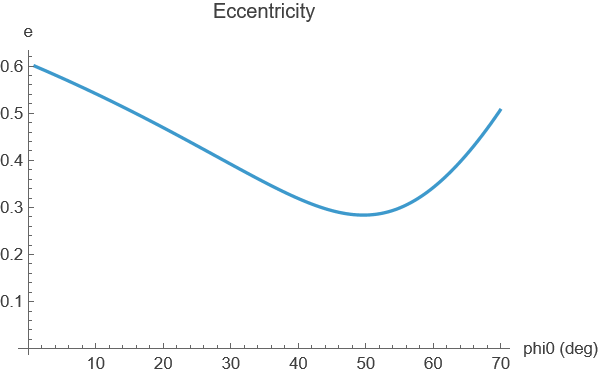
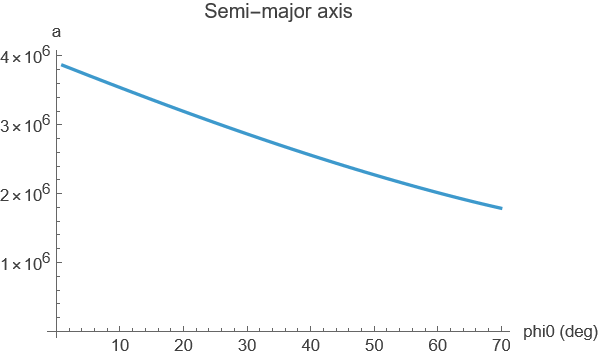
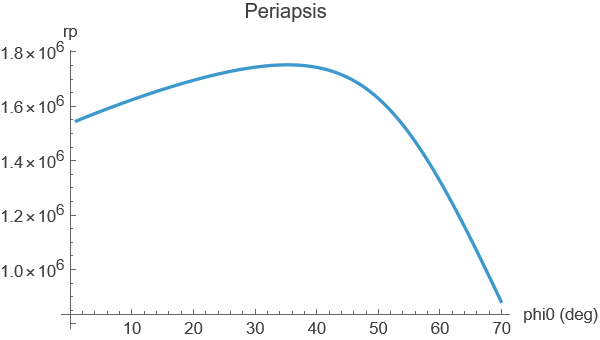
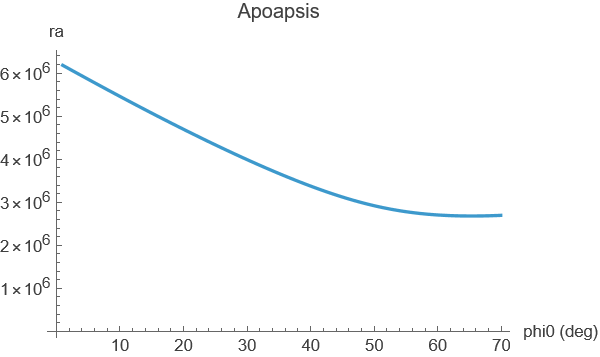
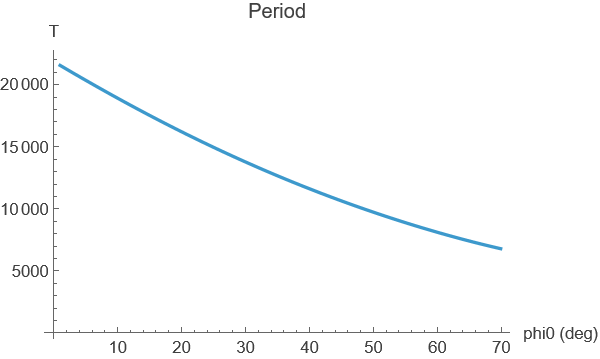
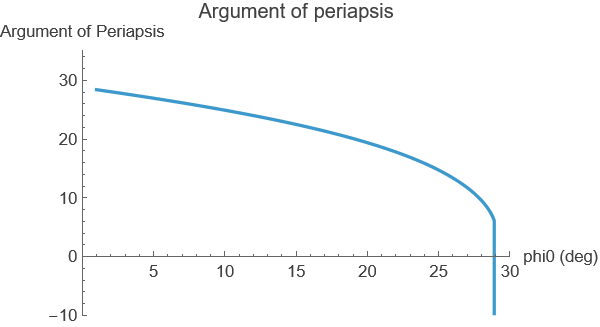

In [1949]:
p1 = ListLinePlot[lSAMpairs, AxesLabel -> {"phi0 (deg)", "lSAM"}, PlotLabel -> "Specific Angular Momentum"];
p2 = ListLinePlot[EnergySpecPairs, AxesLabel -> {"phi0 (deg)", "Energy"}, PlotLabel -> "Specific Energy"];
p3 = ListLinePlot[EccPairs, AxesLabel -> {"phi0 (deg)", "e"}, PlotLabel -> "Eccentricity"]
p4 = ListLinePlot[SMAPairs, AxesLabel -> {"phi0 (deg)", "a"}, PlotLabel -> "Semi-major axis"]
p5 = ListLinePlot[rpPairs, AxesLabel -> {"phi0 (deg)", "rp"}, PlotLabel -> "Periapsis"]
p6 = ListLinePlot[raPairs, AxesLabel -> {"phi0 (deg)", "ra"}, PlotLabel -> "Apoapsis"]
p7 = ListLinePlot[TPairs, AxesLabel -> {"phi0 (deg)", "T"}, PlotLabel -> "Period"]
p8 = ListLinePlot[APPairs, AxesLabel -> {"phi0 (deg)", "Argument of Periapsis"}, PlotLabel -> "Argument of periapsis",PlotRange->{{0,30},{-10,35}}]

**4.** What values of $\phi_{\mathrm{th}}(0)$ provide periapses $r_P > R_{\mathrm{Moon}}$? 

To decide which value of $\phi_{\mathrm{th}}(0)$ we shall use for $r_P > R_{\mathrm{Moon}}$, we need to filter from the list any rp value less than the moon's radius and then display the $\phi_{\mathrm{th}}(0)$ interval of those values:

In [1969]:
safePhi0 = Table[If[rpAMphi0List[[i]] > RadiusMoon, phi0list[[i]], Nothing],{i, 1, Length[phi0list]}];

In [1974]:
Print["Safe phi0 interval:  ", Min[safePhi0], "  ≤  phi0  ≤  ", Max[safePhi0]];

Safe phi0 interval:  28.2  <=  phi0  <=  41.1


**5.** For what value or values of $\phi_{\mathrm{th}}(0)$ can you insert the ascent stage into an orbit as close as possible to the desired preliminary orbit with periapsis and apoapsis altitudes of $9\times 45$ nmi? From the total burn time and the fuel flow rate, calculate the total fuel used. 
How does that compare to the value, $M_{\mathrm{fuel}}$, you had estimated from the rocket equation in Sec. 3.2? 

In [1983]:
rpDesired = RadiusMoon + 9*NauticalMile (* desired periapsis radius (m) *)
raDesired = RadiusMoon + 45*NauticalMile (* desired apoapsis radius (m) *)

6
1.75407 10
          6
1.82074 10

We build an error table: {phi0, error} where $error = (rp - rp_{Desired})^2 + (ra - ra_{Desired})^2$

In [2005]:
errorTable = Table[Module[{rp, ra, err},
    rp = rpAMphi0List[[i]];
    ra = raAMphi0List[[i]];
    err = (rp - rpDesired)^2 + (ra - raDesired)^2;
    {phi0list[[i]], err}],{i, 1, Length[phi0list]}];

(* find index of minimum error *)
bestIndex = 1;
bestErr = errorTable[[1, 2]];
For[i = 2, i <= Length[errorTable], i++,
  If[ errorTable[[i, 2]] < bestErr,
      bestErr = errorTable[[i, 2]];
      bestIndex = i];];

bestPhi0 = errorTable[[bestIndex, 1]]
bestRp = rpAMphi0List[[bestIndex]]
bestRa = raAMphi0List[[bestIndex]]

58.
          6
1.40053 10
          6
2.72834 10

**6.** Condense all the information you have produced into a very short section entitled *Operational phases* along the same lines as in Bennett (pp 13-15). If you need to draw sketches, use such tools as draw.io (diagrams), listed at the Freeplane mind map in my OSF project (https://osf.io/wud3q/). the same information should also appear in your presentation slide. 

**Operational Phases of the Lunar Ascent Stage**

Following Bennett (pp. 13–15), the ascent performed with my randomly generated burn time
T = 448.095 s and a vertical climb of tᵥₑᵣₜ = 10 s, can be divided into four operational phases:

1. Vertical Liftoff Phase (0–10 s)

Initial mass: M₀ = 4700 kg.

Full vertical thrust ($\phi = 90°$).

Rocket accelerates slowly because thrust ≈ weight.

Altitude reached at 30 s matches Apollo record (~1589 ft), validating implementation.

2. Pitch-Over and Tangent Steering Phase (10– s)

A linear-tangent program is used:
$$
\tan\phi_{\mathrm{th}}(t) = \Bigl(1 - {t\over T_{\mathrm{progr}} }\Bigr)\tan\phi_0\, ,
$$ 

with my chosen initial thrusting angle: $\phi_{th}(0)=40$
->Smooth rotation from vertical to nearly horizontal.
->Increasing horizontal velocity 
->Radial velocity decreases as thrust direction changes.

3. Engine Burnout / Orbit Insertion

Using 
$𝑡=𝑇_{vert}+𝑇_{progr}=458.095s$, the final quantities are:

Radius: $\mathrm{r}=1.76901×10^6m$
Radial velocity: 134.77 m/s
Tangential velocity: 1928.2 m/s
Altitude: 31.6 km
Flight-path angle: ~4°
Total velocity: ~1933 m/s
Periapsis & apoapsis: $r_{a}=1.40053×10^6 m, r_{a}= 2.72834 ×10^6 m$ , for $\phi_{th}(0)=58 °$

4. Free-Coast Orbital Flight

After insertion, thrust is zero and the motion proceeds under two-body dynamics.
Integrated until reaching periapsis/apoapsis.
The obtained periapsis is above lunar radius → valid orbit.
The trajectory approaches Bennett’s preliminary orbit but differs due to randomized Tprogr, it the closest for $\phi_{th}(0)=58 °$

**Fuel Use Estimate**

Using: $$
m_{fuel} = \dot{m}\, T_{brun}
$$

with $\dot{m}=5.10476 kg/s$
$$ m_{fuel}= 5.10476 * 458.095 = 2339kg$$

Comparison with theoretical fuel mass from the rocket equation:

Theoretical from Sec. 3.2: ~ 1997.5 kg

Numerical ascent: ~ 2339 kg

The difference is consistent due to:
gravity losses
steering losses

**7.** How would you adapt all you have learned to the Chinese robotic moon missions carried out in recent years?

**Adapting the Model to the Chinese Chang’e Lunar Ascent System**

The Chang’e-5 robotic ascent system performs a fully automated ascent from the lunar surface, carrying samples to rendezvous with an orbiter. Adapting my model requires the following modifications:

1. Updated Physical and Propulsion Parameters

Replace Apollo ascent stage data with Chang’e-5 values:
Launch mass ≈ 3500 kg
Dry mass ≈ 1300 kg
Isp ≈ 315–320 s (different bipropellant engine)
Thrust ≈ 3000 N

All core equations (mass flow, Δv, rocket equation) remain identical; only constants change.

2. Different Mission Geometry

Unlike Apollo, Chang’e missions, we would aim for a 120–200 km circular lunar orbit. Also it must perform automated rendezvous with the orbiter, so it requires stricter accuracy in final orbital elements. Thus, steering laws may use optimal control algorithms rather than simple linear–tangent.

3. Fully Robotic Guidance

With no astronaut safety constraints, we can use steeper pitch angles or more aggressive gravity-turns. Allowing realtime optimization based on IMU (inertial measurement unit) + terrain sensors.

4. Different Ascent Profile

Chinese documents describe:
-A short vertical ascent
-Automated pitch-over
-Continuous closed-loop guidance adjusting burn direction
-Injection into a near-circular orbit rather than an eccentric preliminary orbit

Thus, to simulate Chang’e:
Replace fixed steering law with $\phi(t)$ determined by feedback (e.g., PID or MPC).
Target circular orbit parameters rather than periapsis/apoapsis matching, which I believe it would be much simpler.

5. Verification

Lastly, for a sanity check, we can use the same final calculations: orbital elements,cartesian parameters and validate against published Chang’e-5 trajectory data.

## <a class="anchor" id="References"></a> References 

[Back to Table of Contents](#Table_of_Contents) 


R. R. Bate, D. D. Mueller, and J. E. White, *Fundamentals of Astrodynamics* (Dover Publications, New York, 1971). <br>
https://archive.org/details/BateMuellerAndWhiteFundamentalsOfAstrodynamics/

F. V. Bennett, *Apollo Experience Report - Mission Planning for Lunar Module Descent and Ascent (NASA Technical Note. NASA TN D-6846)* (NASA, Washington, DC, 1972). <br>
https://www.hq.nasa.gov/alsj/nasa-tnd-6846pt.1.pdf

S. C. Fisher and S. A. Rahman, *Remembering the Giants* (NASA, Washington, 2009). <br>
https://history.nasa.gov/monograph45.pdf 

C. Kittel, W. D. Knight, and M. A. Ruderman, *Berkeley Physics Course Vol. 1 (Mechanics)* (McGraw Hill Book Company, New York, 1973). <br>
https://archive.org/details/BerkeleyPhysicsCourse 

A. Miele, "The calculus of variations in applied aerodynamics and flight mechanics," in *Optimization Techniques. With Applications to Aerospace Systems*, Vol. 5, G. Leitmann, Ed. (Academic Press, New York, 1962); pp 99-170 <br>
https://academics.uccs.edu/rcascava/Math9500/Miele1962.pdf 

W. T. Thomson, *Introduction to Space Dynamics* (Dover Publications, Mineola, NW, 1986). pp 404 ff PDF Appendix C. <br>
https://soaneemrana.org/onewebmedia/INTRODUCTION%20TO%20SPACE%20DYNAMICS1.pdf  

M. J. L. Turner, *Rocket and Spacecraft Propulsion* (Springer, Berlin, 2009). Ch. 5. <br>
https://www.academia.edu/43217896/Rocket_and_Spacecraft_Propulsion_Principles_Practice_and_New_Developments_Third_Edition  



## <a class="anchor" id="ChangeLog"></a> ChangeLog

[Back to Table of Contents](#Table_of_Contents) 

### v. 1.0

2023-11-15&nbsp;&nbsp; Fabrizio Pinto&nbsp;&nbsp; fabriziopinto2013@gmail.com  

* File created. 

## <a class="anchor" id="ChangeLog"></a> ChangeLog

[Back to Table of Contents](#Table_of_Contents) 

### v. 1.1

2024-11-22&nbsp;&nbsp; Fabrizio Pinto&nbsp;&nbsp; fabriziopinto2013@gmail.com  

* File updated. 

### v. 1.2

2025-11-27&nbsp;&nbsp; Fabrizio Pinto&nbsp;&nbsp; fabriziopinto2013@gmail.com  

* An error in the Mathematica code for SpecAngMom [rp_, ra_] = Sqrt[kMoon SMA[rp, ra] ((1 - (Eccentricity[rp, ra])^2))] was corrected. 